In [ ]:
# STEP 6: Export Analysis Results
print("\n" + "="*120)
print("💾 EXPORT ROUTING ANALYSIS")
print("="*120)

# Create clean export format
export_df = routing_df[['issuer', 'processor', 'aff1_approval_rate', 'aff15_approval_rate', 
                         'approval_gap', 'aff1_volume', 'aff15_volume', 'total_volume']].copy()

export_df.columns = ['Issuer', 'Processor', 'Aff1_SR_%', 'Aff15_SR_%', 
                     'Gap_%', 'Aff1_Volume', 'Aff15_Volume', 'Total_Volume']

# Save to Excel
export_filename = 'routing_analysis_affiliate_issuer_processor.xlsx'
export_df.to_excel(export_filename, index=False, sheet_name='Routing_Analysis')

print(f"✅ Exported routing analysis to: {export_filename}")
print(f"   Rows: {len(export_df):,}")
print(f"   Columns: {len(export_df.columns)}")

# Display final summary
print(f"\n📈 SUMMARY STATISTICS:")
print(f"   Total combinations analyzed: {len(routing_df):,}")
print(f"   Average gap (Aff15 - Aff1): {routing_df['approval_gap'].mean():+.2f}%")
print(f"   Max gap (Aff15 better): {routing_df['approval_gap'].max():+.2f}%")
print(f"   Max gap (Aff1 better): {routing_df['approval_gap'].min():+.2f}%")
print(f"   Combinations where Aff15 > Aff1: {(routing_df['approval_gap'] > 0).sum():,} ({(routing_df['approval_gap'] > 0).sum()/len(routing_df)*100:.1f}%)")
print(f"   Combinations where Aff1 > Aff15: {(routing_df['approval_gap'] < 0).sum():,} ({(routing_df['approval_gap'] < 0).sum()/len(routing_df)*100:.1f}%)")

print("\n" + "="*120)
print("✅ ROUTING ANALYSIS COMPLETE")
print("="*120)

In [ ]:
# STEP 5: Processor Performance Breakdown by Issuer
print("\n" + "="*120)
print("📊 PROCESSOR PERFORMANCE BY TOP ISSUERS")
print("="*120)

# Get top 10 issuers by volume
top_issuers = routing_df.groupby('issuer')['total_volume'].sum().nlargest(10).index

for issuer in top_issuers:
    issuer_data = routing_df[routing_df['issuer'] == issuer].copy()
    
    if len(issuer_data) == 0:
        continue
    
    # Sort by total volume for this issuer
    issuer_data = issuer_data.sort_values('total_volume', ascending=False)
    
    print(f"\n🏦 {issuer}")
    print(f"   {'Processor':<25} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Gap':>8} {'Aff1 Vol':>10} {'Aff15 Vol':>10}")
    print("   " + "-"*80)
    
    for _, row in issuer_data.head(5).iterrows():  # Top 5 processors for this issuer
        gap_indicator = "⬆️" if row['approval_gap'] > 0 else "⬇️"
        print(f"   {row['processor']:<25} {row['aff1_approval_rate']:>9.2f}% {row['aff15_approval_rate']:>9.2f}% "
              f"{row['approval_gap']:>+7.2f}% {row['aff1_volume']:>10,} {row['aff15_volume']:>10,} {gap_indicator}")

In [ ]:
# STEP 4: Focus on High-Volume, High-Gap Combinations
print("\n" + "="*120)
print("🔥 BIGGEST ROUTING OPPORTUNITIES (High Volume + Large Gap)")
print("="*120)

# Filter for combinations with meaningful volume and significant gaps
min_volume = 1000  # At least 1,000 total transactions
min_gap = 3.0      # At least 3pp difference

opportunities = routing_df[
    (routing_df['total_volume'] >= min_volume) & 
    (abs(routing_df['approval_gap']) >= min_gap)
].sort_values('approval_gap', ascending=False)

print(f"\nFound {len(opportunities)} routing opportunities (volume ≥ {min_volume:,}, gap ≥ {min_gap}%)")
print(f"\n{'Issuer':<35} {'Processor':<20} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Gap':>8} {'Total Vol':>10} {'Winner':>10}")
print("-"*120)

for idx, row in opportunities.iterrows():
    winner = "Aff15 ✅" if row['approval_gap'] > 0 else "Aff1 ✅"
    print(f"{row['issuer']:<35} {row['processor']:<20} "
          f"{row['aff1_approval_rate']:>9.2f}% {row['aff15_approval_rate']:>9.2f}% "
          f"{row['approval_gap']:>+7.2f}% {row['total_volume']:>10,} {winner:>10}")

# Calculate potential impact
if len(opportunities) > 0:
    total_opportunity_volume = opportunities['total_volume'].sum()
    avg_gap = opportunities['approval_gap'].mean()
    
    print(f"\n📊 POTENTIAL IMPACT:")
    print(f"   Total volume in these opportunities: {total_opportunity_volume:,} transactions")
    print(f"   Average approval gap: {avg_gap:+.2f}%")
    print(f"   If we could replicate Aff15's performance on Aff1:")
    print(f"   → Potential additional approvals: ~{int(total_opportunity_volume * 0.76 * abs(avg_gap) / 100):,} transactions")
else:
    print("\nNo significant routing opportunities found with current filters.")

In [ ]:
# STEP 3: Detailed Analysis - Top Combinations by Volume
print("="*120)
print("🎯 TOP 20 ISSUER × PROCESSOR COMBINATIONS (by Volume)")
print("="*120)
print(f"{'Issuer':<35} {'Processor':<20} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Gap':>8} {'Aff1 Vol':>10} {'Aff15 Vol':>10} {'Total':>10}")
print("-"*120)

for idx, row in routing_df.head(20).iterrows():
    gap_str = f"{row['approval_gap']:+.2f}%"
    indicator = "✅" if abs(row['approval_gap']) < 2 else ("🟡" if abs(row['approval_gap']) < 5 else "🔴")
    
    print(f"{row['issuer']:<35} {row['processor']:<20} "
          f"{row['aff1_approval_rate']:>9.2f}% {row['aff15_approval_rate']:>9.2f}% "
          f"{gap_str:>8} {row['aff1_volume']:>10,} {row['aff15_volume']:>10,} "
          f"{row['total_volume']:>10,} {indicator}")

print("\n" + "="*120)
print("Legend: ✅ <2% gap (similar) | 🟡 2-5% gap (moderate) | 🔴 >5% gap (significant)")
print("="*120)

In [ ]:
# STEP 2: Create Comparison DataFrame - Affiliate × Issuer × Processor
print("="*100)
print("🔄 BUILDING AFFILIATE × ISSUER × PROCESSOR COMPARISON")
print("="*100)

# Group by affiliate, issuer, and processor
routing_analysis = []

for issuer in pooled_df['issuer_name'].unique():
    if issuer == 'Unknown':
        continue
        
    for processor in pooled_df['processor_name'].unique():
        if processor == 'Unknown':
            continue
        
        # Filter for this issuer × processor combination
        combo_data = pooled_df[(pooled_df['issuer_name'] == issuer) & 
                               (pooled_df['processor_name'] == processor)]
        
        if len(combo_data) == 0:
            continue
        
        # Split by affiliate
        aff1_data = combo_data[combo_data['affiliate_id'] == 1]
        aff15_data = combo_data[combo_data['affiliate_id'] == 15]
        
        # Only include if both affiliates have data for this combo
        if len(aff1_data) > 0 and len(aff15_data) > 0:
            aff1_sr = aff1_data['success_charge_ratess'].mean() * 100
            aff15_sr = aff15_data['success_charge_ratess'].mean() * 100
            aff1_vol = aff1_data['attempted_charges'].sum()
            aff15_vol = aff15_data['attempted_charges'].sum()
            
            routing_analysis.append({
                'issuer': issuer,
                'processor': processor,
                'aff1_approval_rate': aff1_sr,
                'aff15_approval_rate': aff15_sr,
                'aff1_volume': aff1_vol,
                'aff15_volume': aff15_vol,
                'total_volume': aff1_vol + aff15_vol,
                'approval_gap': aff15_sr - aff1_sr,  # Positive = Aff15 better
                'approval_gap_pct': ((aff15_sr - aff1_sr) / max(aff1_sr, 0.01)) * 100,
                'aff1_revenue': aff1_data['gross_product_revenue'].sum(),
                'aff15_revenue': aff15_data['gross_product_revenue'].sum()
            })

# Create DataFrame
routing_df = pd.DataFrame(routing_analysis)

# Sort by total volume (most important combinations first)
routing_df = routing_df.sort_values('total_volume', ascending=False)

print(f"\n✅ Created routing analysis with {len(routing_df)} Issuer × Processor combinations")
print(f"   (combinations that exist in BOTH affiliates)")
print(f"\nTotal volume covered: {routing_df['total_volume'].sum():,} transactions")
print(f"Coverage: {routing_df['total_volume'].sum() / pooled_df['attempted_charges'].sum() * 100:.1f}% of all transactions")

# Display summary
routing_df.head(20)

In [ ]:
# STEP 1: Build Affiliate × Issuer × Processor Performance Matrix
import pandas as pd
import numpy as np

# Get all bank issuer and processor columns
bank_issuer_cols = [col for col in pooled_df.columns if col.startswith('bankissuer_')]
processor_cols = [col for col in pooled_df.columns if col.startswith('processor_')]

print(f"Total Bank Issuers: {len(bank_issuer_cols)}")
print(f"Total Processors: {len(processor_cols)}")

# Function to get active issuer and processor for each row
def get_active_column(row, col_list):
    """Return the name of the active (value=1) column from a list"""
    for col in col_list:
        if col in row.index and row[col] == 1:
            return col.replace('bankissuer_', '').replace('processor_', '').replace('_', ' ').title()
    return 'Unknown'

# Add issuer and processor names to dataframe
pooled_df['issuer_name'] = pooled_df.apply(lambda row: get_active_column(row, bank_issuer_cols), axis=1)
pooled_df['processor_name'] = pooled_df.apply(lambda row: get_active_column(row, processor_cols), axis=1)

print("\n✅ Added issuer_name and processor_name columns to pooled_df")
print(f"Unique issuers: {pooled_df['issuer_name'].nunique()}")
print(f"Unique processors: {pooled_df['processor_name'].nunique()}")

## 2. AFFILIATE × ISSUER × PROCESSOR ROUTING ANALYSIS

**Objective**: Identify if certain processors perform better for specific Bank Issuers on different affiliates

This analysis will reveal if we can optimize routing by directing specific Affiliate+Issuer combinations to better-performing processors.

# Operational Analysis - BIN-Based Routing Optimization

This notebook analyzes Card BIN × Processor performance to identify optimal routing strategies.

## Index
- [Introduction](#introduction)



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76969 entries, 0 to 76968
Data columns (total 73 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Merchant                            76969 non-null  object 
 1   <track>Tracking 1</track>           76965 non-null  float64
 2   <track>Tracking 2</track>           76969 non-null  object 
 3   Item                                76969 non-null  object 
 4   Card Type                           76966 non-null  object 
 5   Transaction Day Of Week             76969 non-null  object 
 6   Card Bin Number                     76966 non-null  float64
 7   Attempted Charges                   76969 non-null  int64  
 8   Declined Charges                    76969 non-null  int64  
 9   Declined Charge Rate                76969 non-null  object 
 10  Successful Charges                  76969 non-null  int64  
 11  Success Charge Rate       

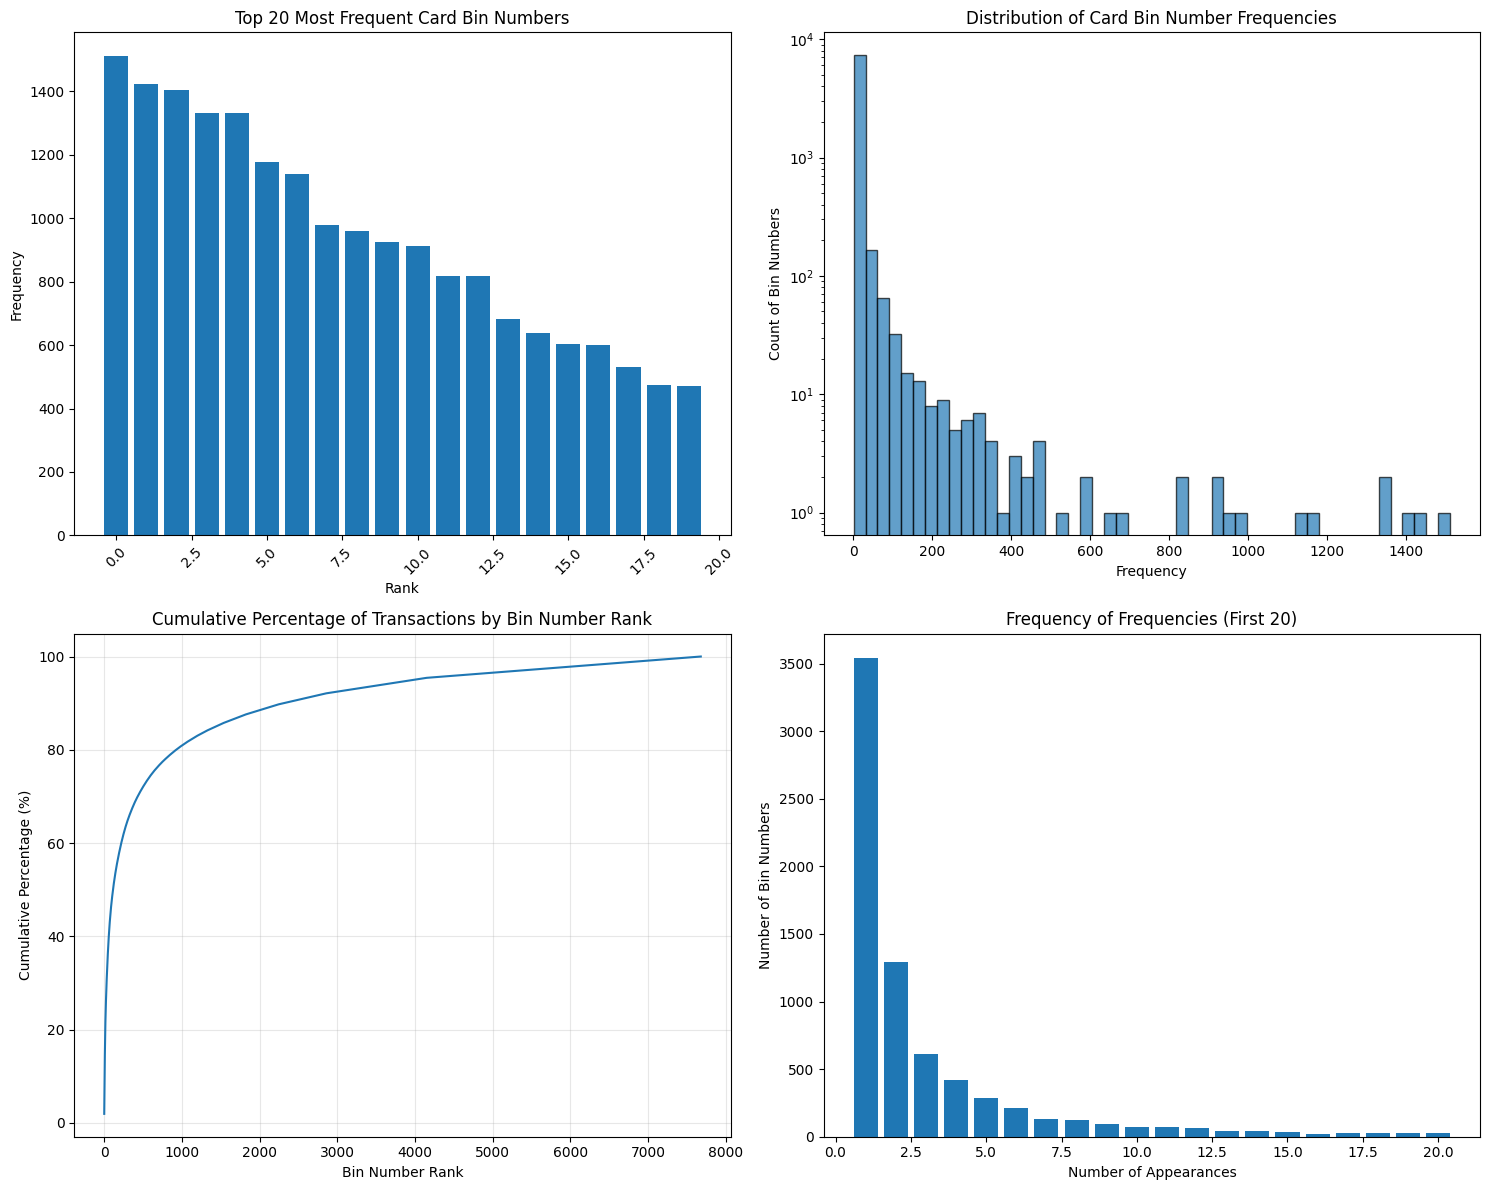


Coverage analysis:
Top 10 bin numbers cover: 15.78% of transactions
Top 50 bin numbers cover: 37.21% of transactions
Top 100 bin numbers cover: 48.07% of transactions
Top 500 bin numbers cover: 72.05% of transactions
BIN Database Info:
Shape: (374788, 10)
Columns: ['BIN', 'Brand', 'Type', 'Category', 'Issuer', 'IssuerPhone', 'IssuerUrl', 'isoCode2', 'isoCode3', 'CountryName']

First few rows of BIN database:
Total unique BINs in Decay_Data: 7678
Sample BINs from Decay_Data: [514377 515676 534456 546316 411773 412451 414720 420767 425836 434275]

Unique 6-digit BIN prefixes in Decay_Data: 7678

BIN database columns: ['BIN', 'Issuer']
Total BINs in BIN database: 374788

=== MATCHING RESULTS ===
BINs with matches: 7673
BINs without matches: 5
Match rate: 99.93%

Sample matched BINs: ['447212', '542403', '546604', '557568', '517063', '515239', '402464', '473806', '445220', '413331']
Sample unmatched BINs: ['545676', '559659', '514032', '512148', '521999']

=== TRANSACTION COVERAGE ===
Tra

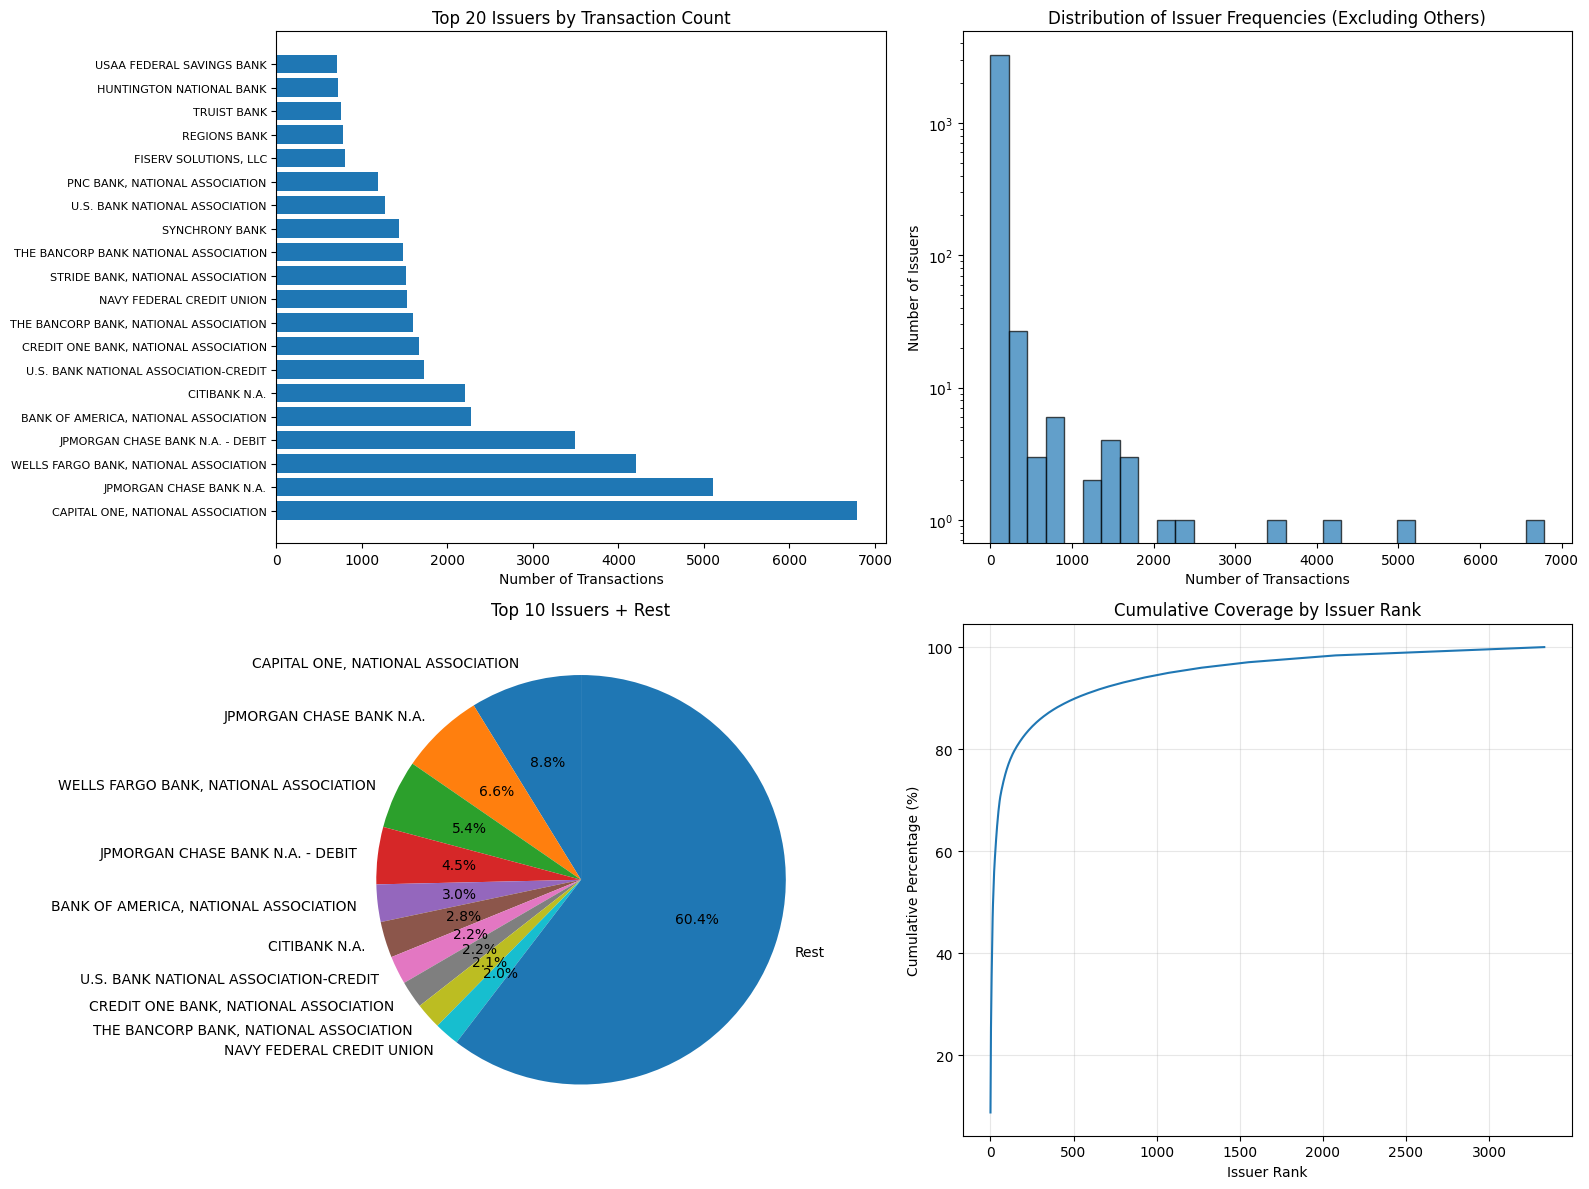


=== SUMMARY ===
Total unique issuers found: 3334
Top 10 issuers cover: 39.60% of transactions
Top 20 issuers cover: 53.39% of transactions
'Others' category: 0.01% of transactions
🏦 CARD ISSUER COVERAGE BY TOP N ISSUERS
Total Transactions: 77,232
Top N Issuers        Coverage (%)
---------------------------------
Top 5                       28.31
Top 10                      39.60
Top 20                      53.39
Top 30                      59.98
Top 40                      64.58
Top 50                      68.16
Top 60                      70.69
Top 70                      72.36
Top 80                      73.80
Top 90                      75.06
Top 100                     76.17
Top 110                     77.13
Top 150                     80.00
Top 200                     82.48


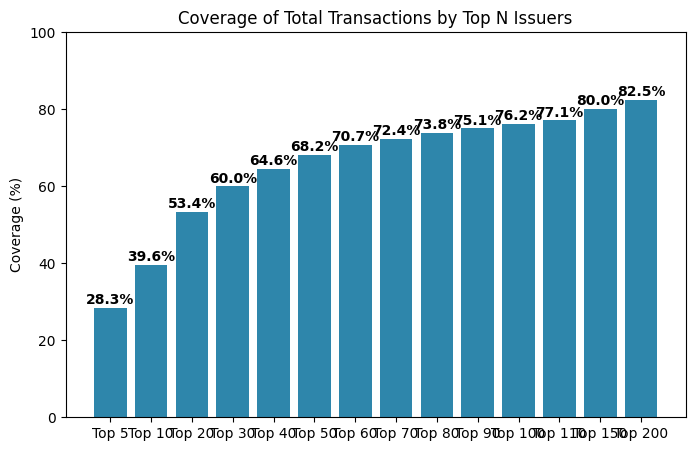

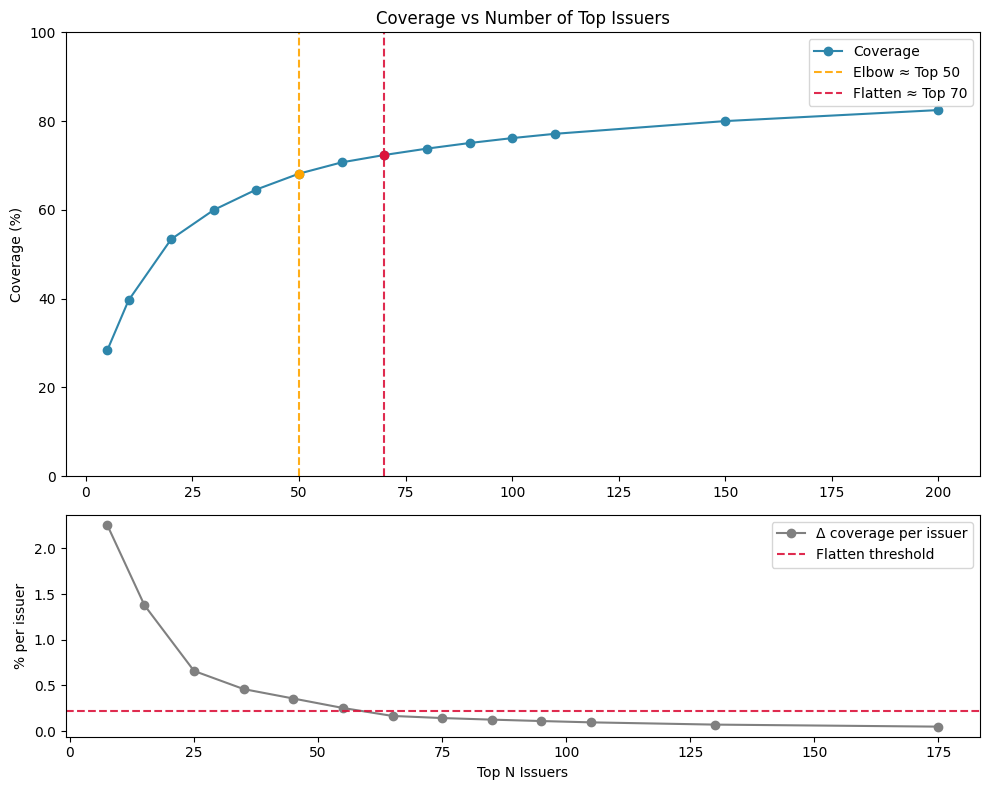

Elbow (knee): Top 50 issuers, coverage ≈ 68.16%
Flattening (≤10% of initial marginal gain): Top 70 issuers, coverage ≈ 72.36%
The length of the bin_database is (7673, 2)
The number of unique BINs in the bin_database is 7673
=== CREATING BANK_ISSUER COLUMN USING BIN DATABASE MAPPING ===
Mapping BIN numbers to bank issuers using bin_database_dict...
Starting loop over 77,232 rows...
Processed 10,000 rows...
Processed 20,000 rows...
Processed 30,000 rows...
Processed 40,000 rows...
Processed 50,000 rows...
Processed 60,000 rows...
Processed 70,000 rows...
Completed mapping for 77,232 rows

=== BANK_ISSUER MAPPING RESULTS ===
Total unique bank issuers: 3333
Matched transactions: 77,227 (99.99%)
Unmatched transactions (other_bank): 5 (0.01%)

Top 15 bank issuers:
bank_issuer
CAPITAL ONE, NATIONAL ASSOCIATION         6786
JPMORGAN CHASE BANK N.A.                  5108
WELLS FARGO BANK, NATIONAL ASSOCIATION    4205
JPMORGAN CHASE BANK N.A. - DEBIT          3486
BANK OF AMERICA, NATIONAL ASSOC

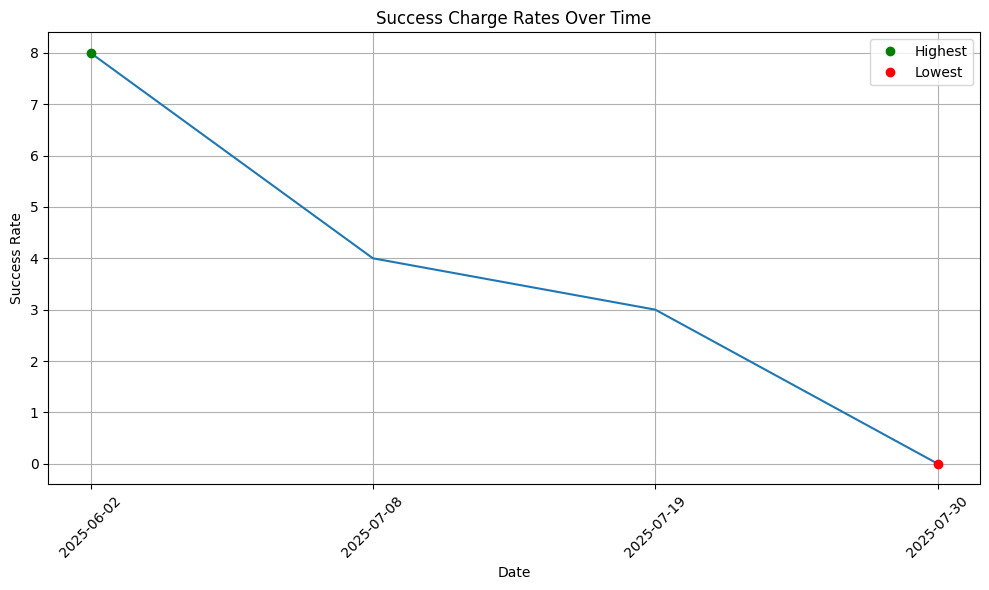

Highest success rate: 0.500 on 2025-06-02
Lowest success rate: 0.000 on 2025-07-30


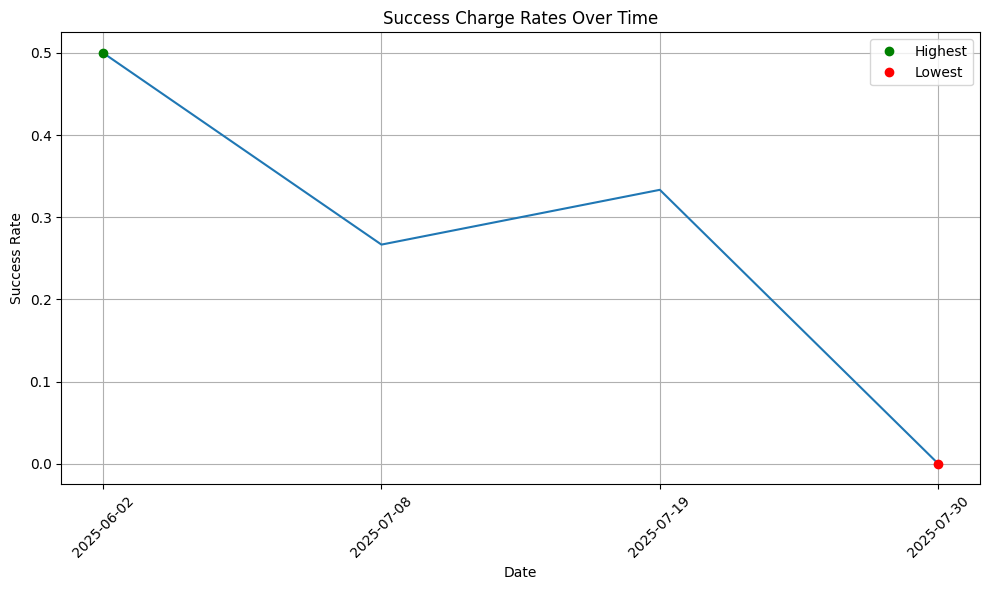

Available dataframes:
mid_dataframes_uncleaned type: <class 'dict'>
Keys: ['11_df', '14_df', '16_df', '17_df', '19_df', '20_df', '22_df', '24_df', '25_df', '27_df', '28_df', '29_df', '3_df', '30_df', '31_df', '32_df', '33_df', '34_df', '37_df', '39_df', '4_df', '40_df', '44_df', '46_df', '47_df', '49_df', '5_df', '50_df', '52_df', '57_df', '62_df', '63_df', '64_df', '65_df', '66_df', '68_df', '69_df', '71_df', '75_df', '8_df', '81_df', '41_df', '48_df', '51_df', '53_df', '59_df', '100_df', '101_df', '102_df', '103_df', '104_df', '105_df', '110_df', '111_df', '112_df', '12_df', '21_df', '35_df', '43_df', '58_df', '60_df', '67_df', '7_df', '77_df', '89_df', '91_df', '92_df', '93_df', '94_df', '95_df', '96_df', '99_df', '116_df', '117_df', '118_df', '119_df', '120_df', '124_df', '125_df', '126_df', '127_df', '128_df', '129_df', '131_df', '132_df', '133_df', '134_df', '87_df', '135_df', '136_df', '121_df', '122_df', '123_df', '137_df', '143_df', '144_df', '72_df', '86_df', '73_df', '13_df'

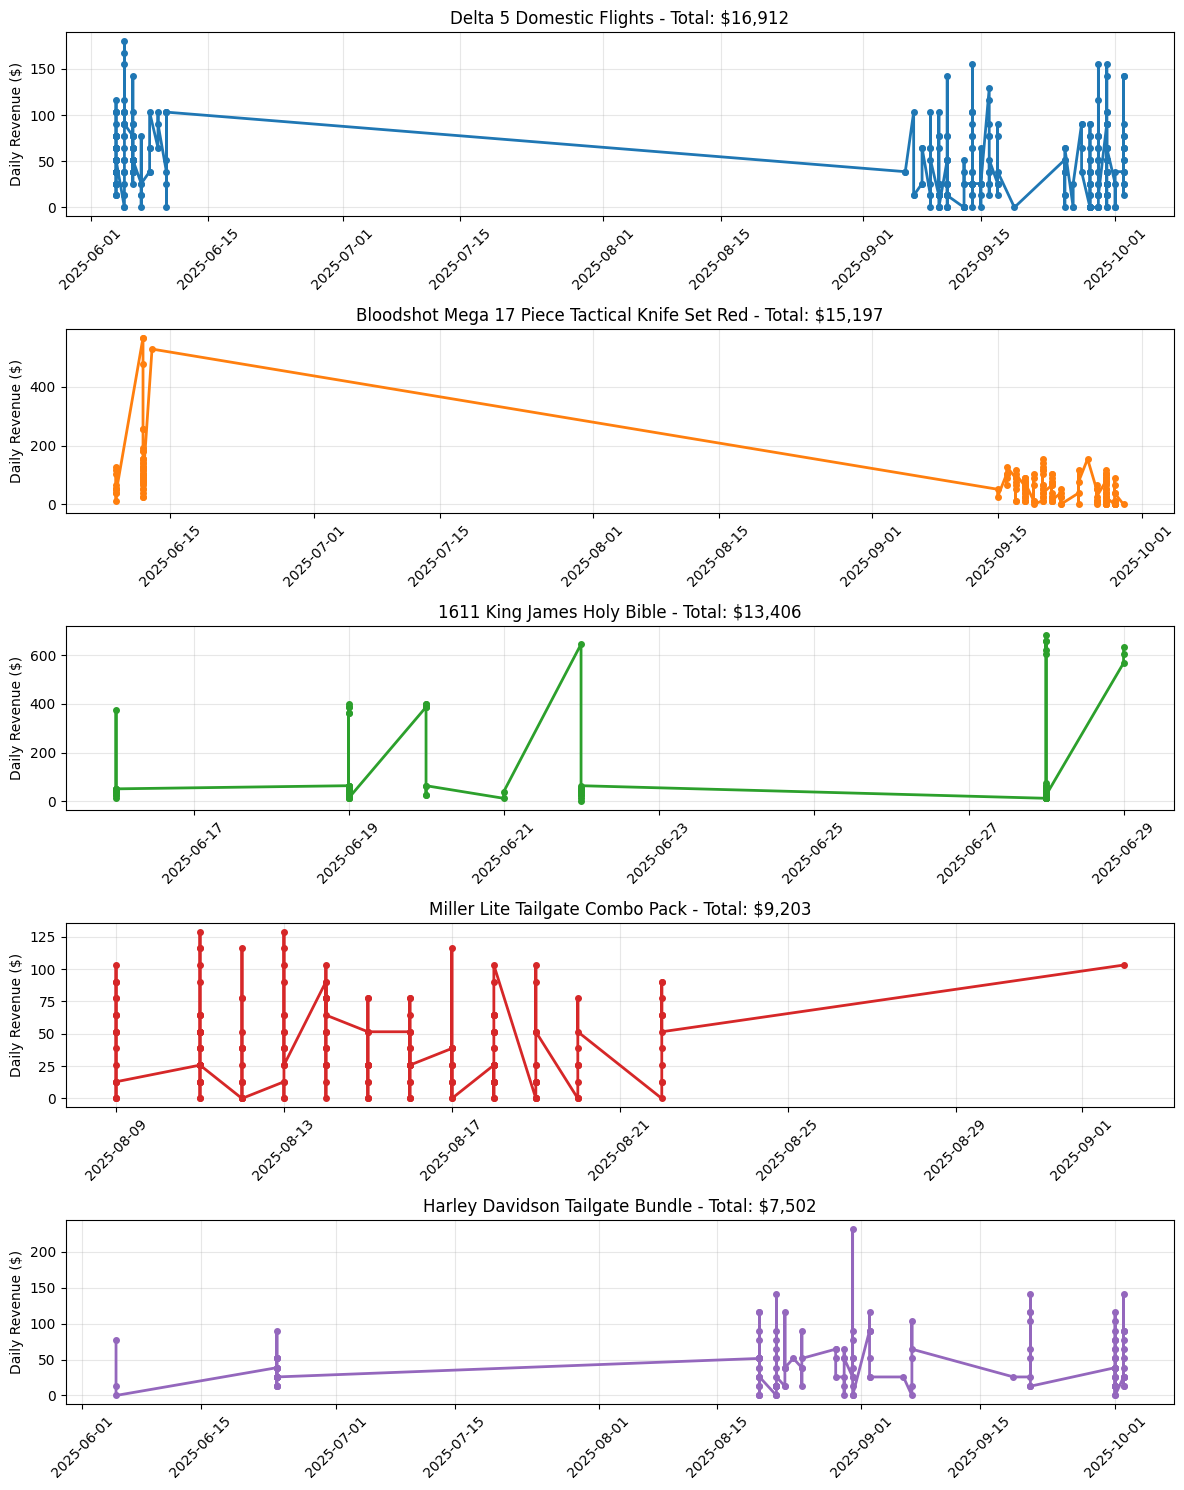

SUCCESS RATE STANDARD DEVIATIONS
Affiliate 1:  0.2253 (22.53%)
Affiliate 15: 0.1836 (18.36%)

Difference:   0.0417
Affiliate 1 has 22.7% more variance


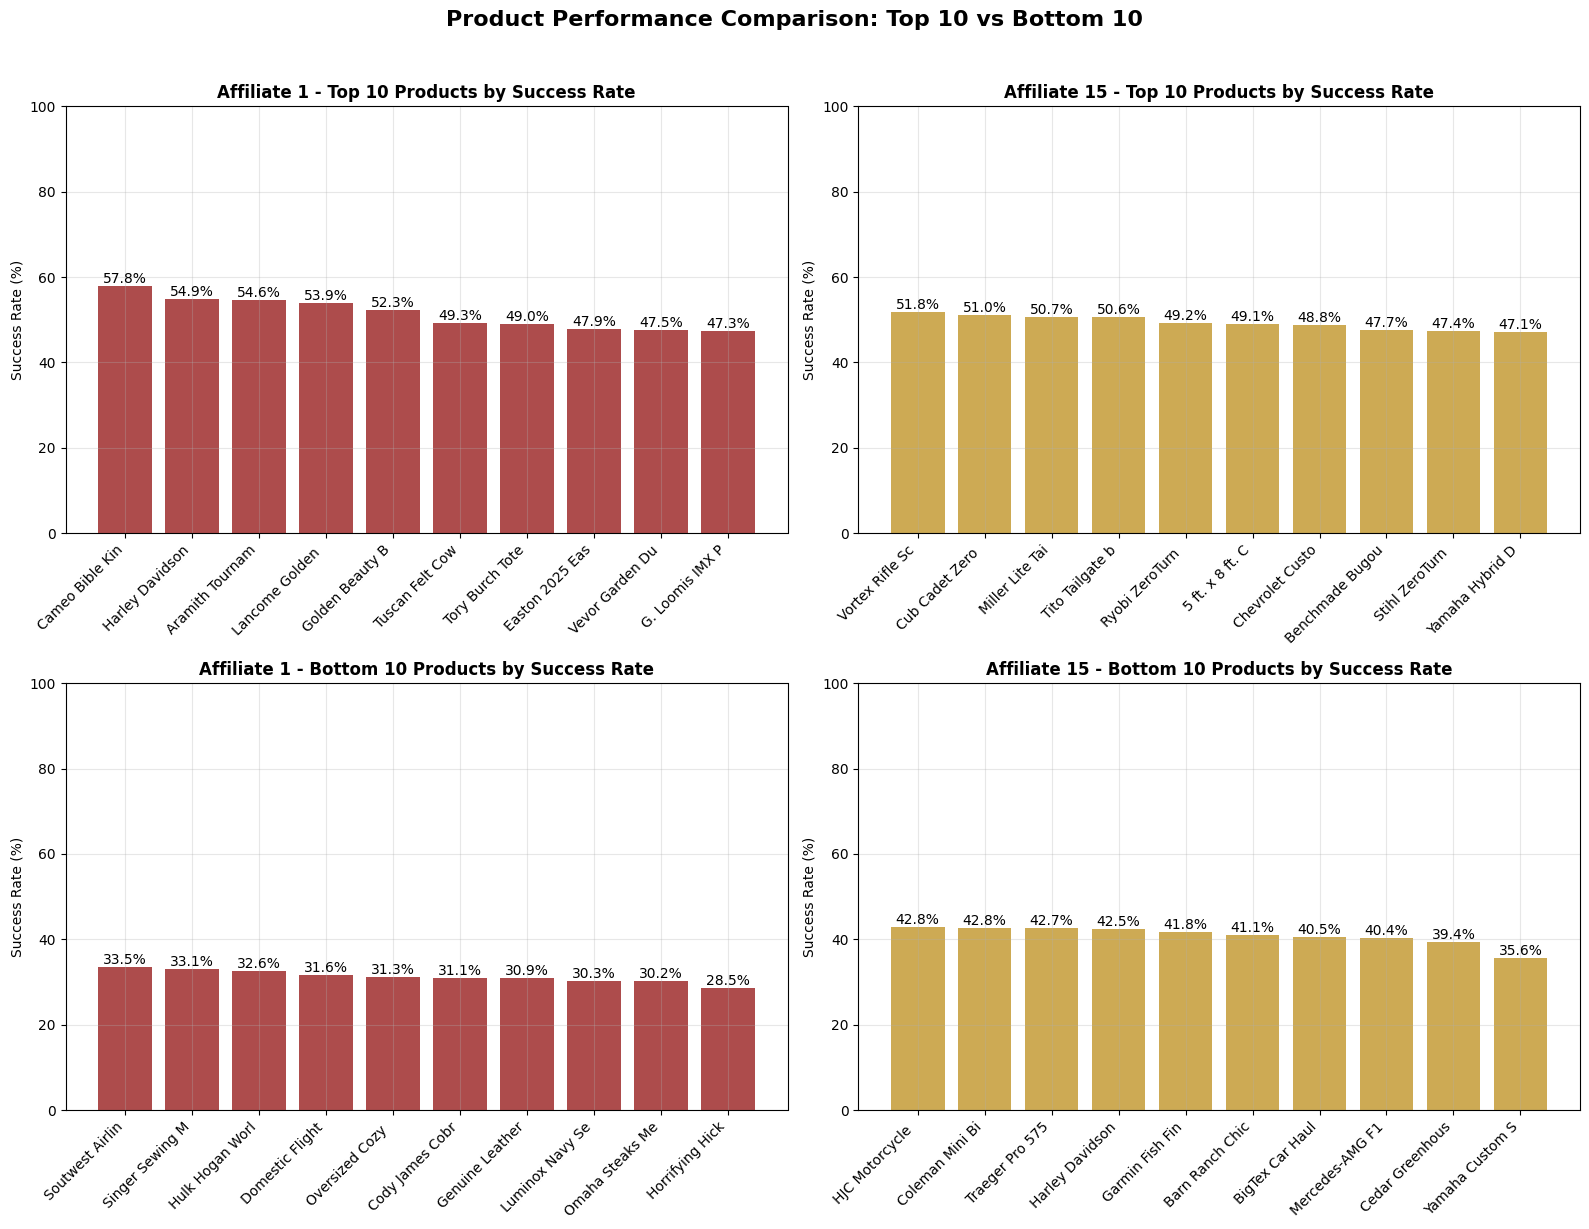

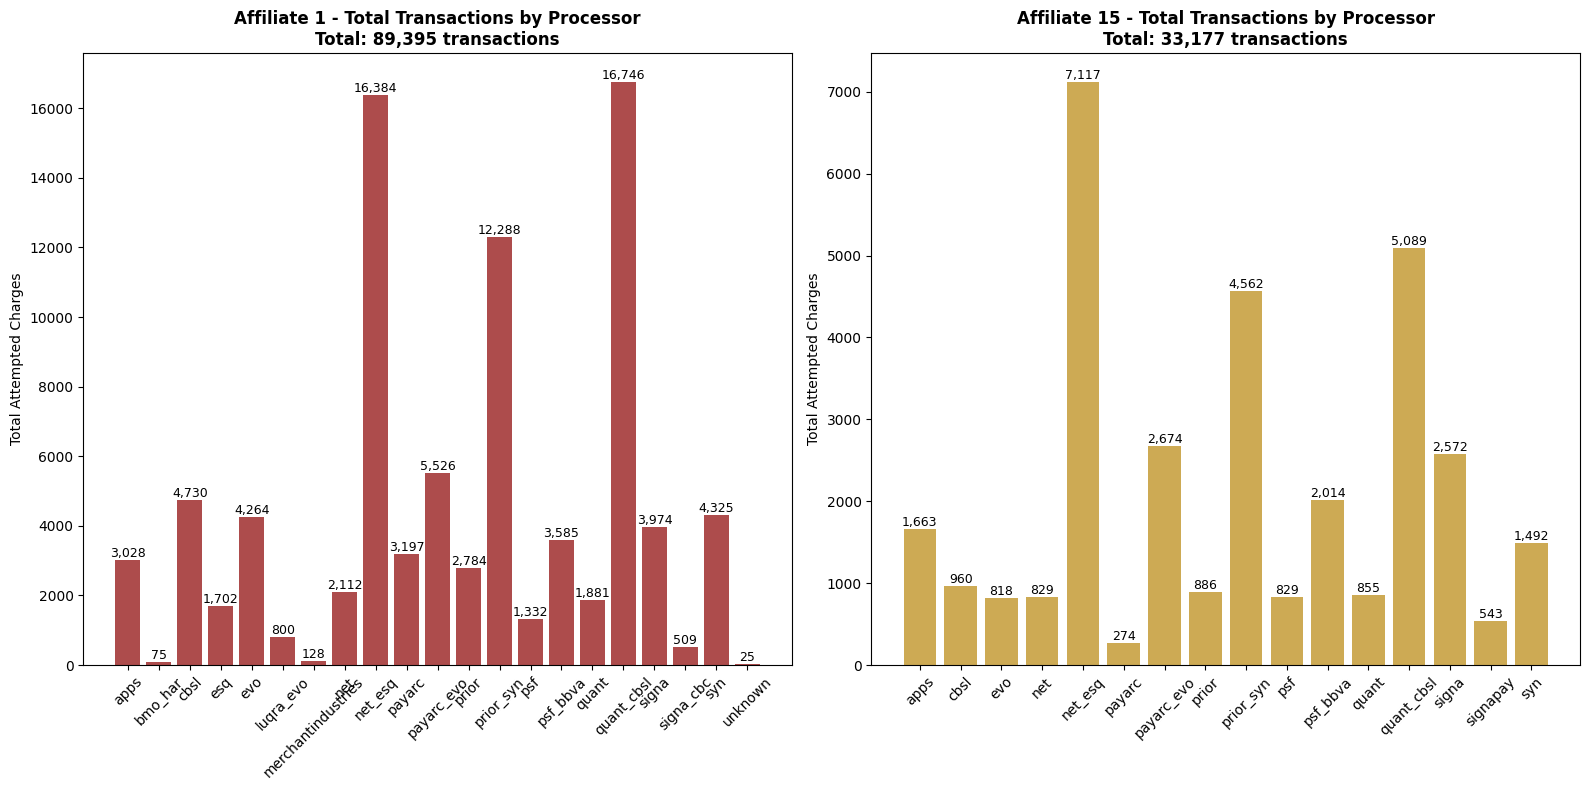


PROCESSOR USAGE COMPARISON:

AFFILIATE 1 PROCESSORS:
------------------------------
quant_cbsl          : 16,746 transactions
net_esq             : 16,384 transactions
prior_syn           : 12,288 transactions
payarc_evo          : 5,526 transactions
cbsl                : 4,730 transactions
syn                 : 4,325 transactions
evo                 : 4,264 transactions
signa               : 3,974 transactions
psf_bbva            : 3,585 transactions
payarc              : 3,197 transactions
apps                : 3,028 transactions
prior               : 2,784 transactions
net                 : 2,112 transactions
quant               : 1,881 transactions
esq                 : 1,702 transactions
psf                 : 1,332 transactions
luqra_evo           : 800 transactions
signa_cbc           : 509 transactions
merchantindustries  : 128 transactions
bmo_har             : 75 transactions
unknown             : 25 transactions

AFFILIATE 15 PROCESSORS:
------------------------------
net_es

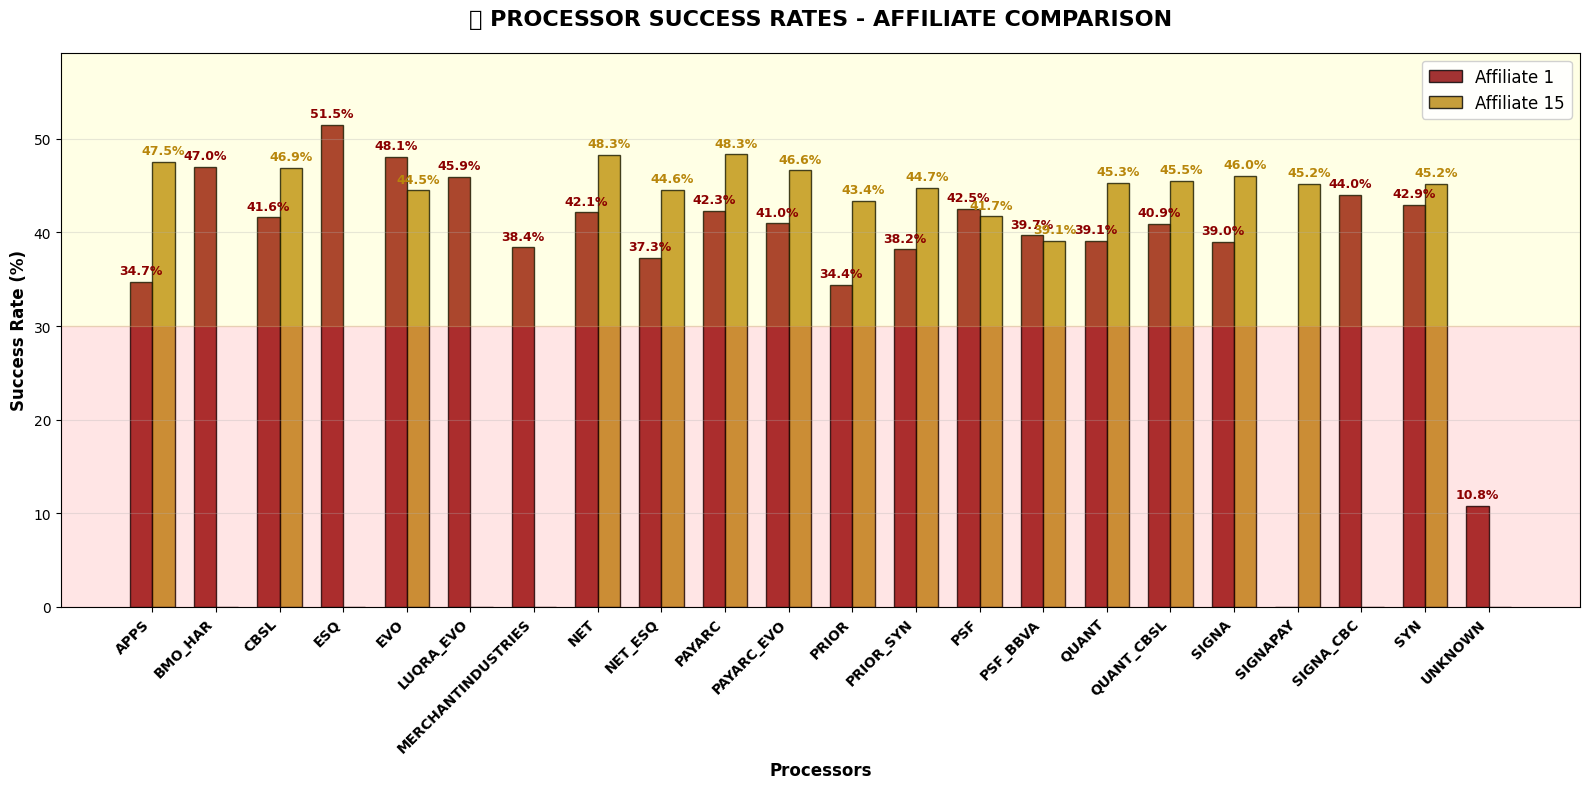


📈 PROCESSOR SUCCESS RATE COMPARISON BY AFFILIATE
Processor            Affiliate 1     Affiliate 15    Difference      Winner    
--------------------------------------------------------------------------------
APPS                 34.7            47.5            12.8            Aff 15    
BMO_HAR              47.0            N/A             N/A             Aff 1 only
CBSL                 41.6            46.9            5.3             Aff 15    
ESQ                  51.5            N/A             N/A             Aff 1 only
EVO                  48.1            44.5            3.6             Aff 1     
LUQRA_EVO            45.9            N/A             N/A             Aff 1 only
MERCHANTINDUSTRIES   38.4            N/A             N/A             Aff 1 only
NET                  42.1            48.3            6.2             Aff 15    
NET_ESQ              37.3            44.6            7.3             Aff 15    
PAYARC               42.3            48.3            6.1             

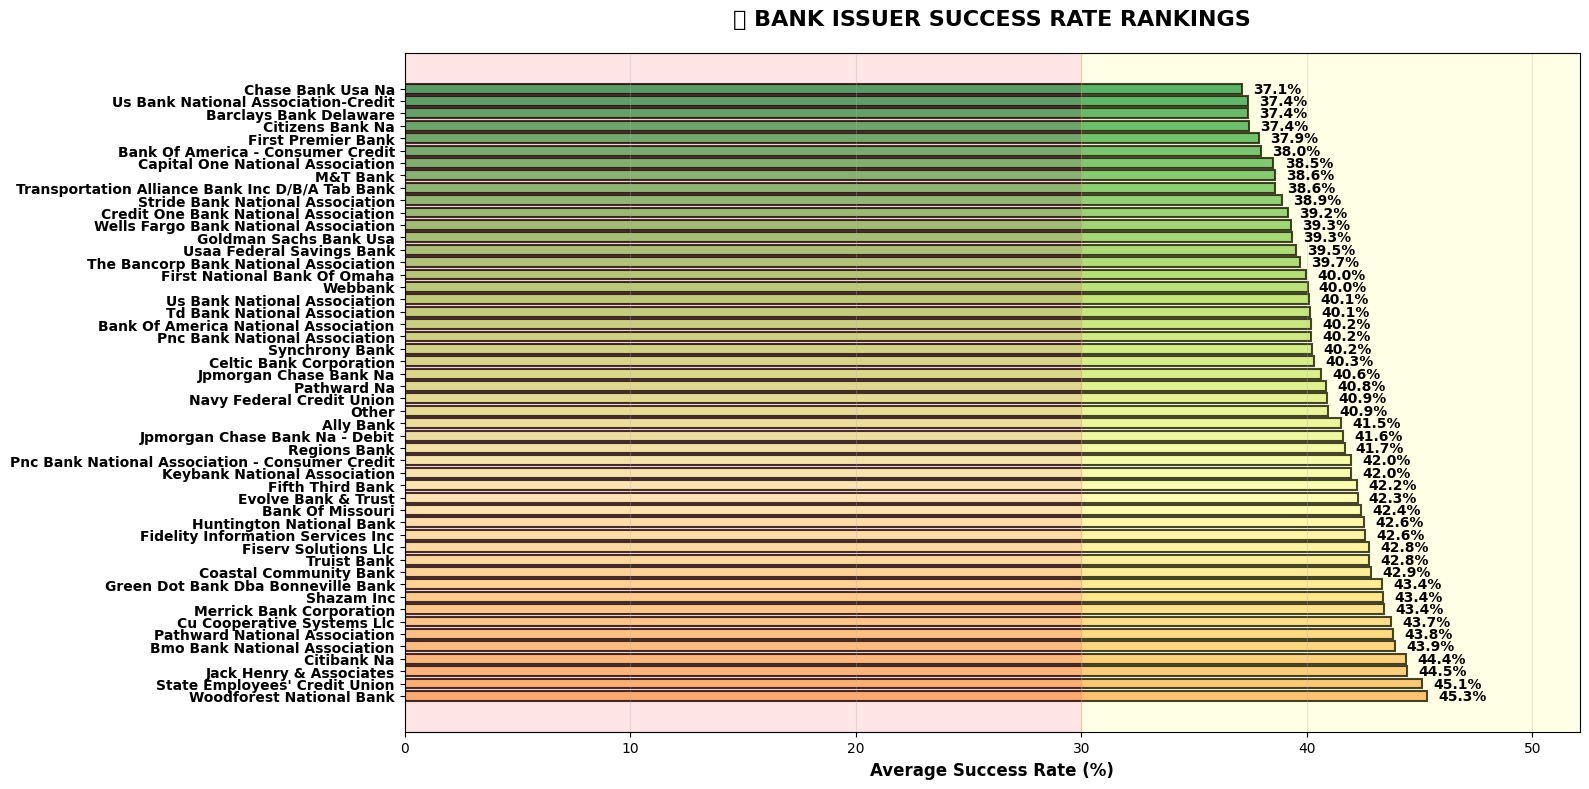


🏦 BANK ISSUER PERFORMANCE ANALYSIS

🥇 TOP 5 PERFORMING BANK ISSUERS:
   1. Woodforest National Bank                 | Success: 45.3% | Volume: 7,358 | Revenue: $43,697
   2. State Employees' Credit Union            | Success: 45.1% | Volume: 6,527 | Revenue: $38,335
   3. Jack Henry & Associates                  | Success: 44.5% | Volume: 8,048 | Revenue: $46,597
   4. Citibank Na                              | Success: 44.4% | Volume: 29,030 | Revenue: $164,115
   5. Bmo Bank National Association            | Success: 43.9% | Volume: 5,518 | Revenue: $31,813

🥉 BOTTOM 5 PERFORMING BANK ISSUERS:
   1. First Premier Bank                       | Success: 37.9% | Volume: 5,653 | Revenue: $28,861
   2. Citizens Bank Na                         | Success: 37.4% | Volume: 6,357 | Revenue: $33,037
   3. Barclays Bank Delaware                   | Success: 37.4% | Volume: 11,335 | Revenue: $60,647
   4. Us Bank National Association-Credit      | Success: 37.4% | Volume: 24,851 | Revenue: $128,7

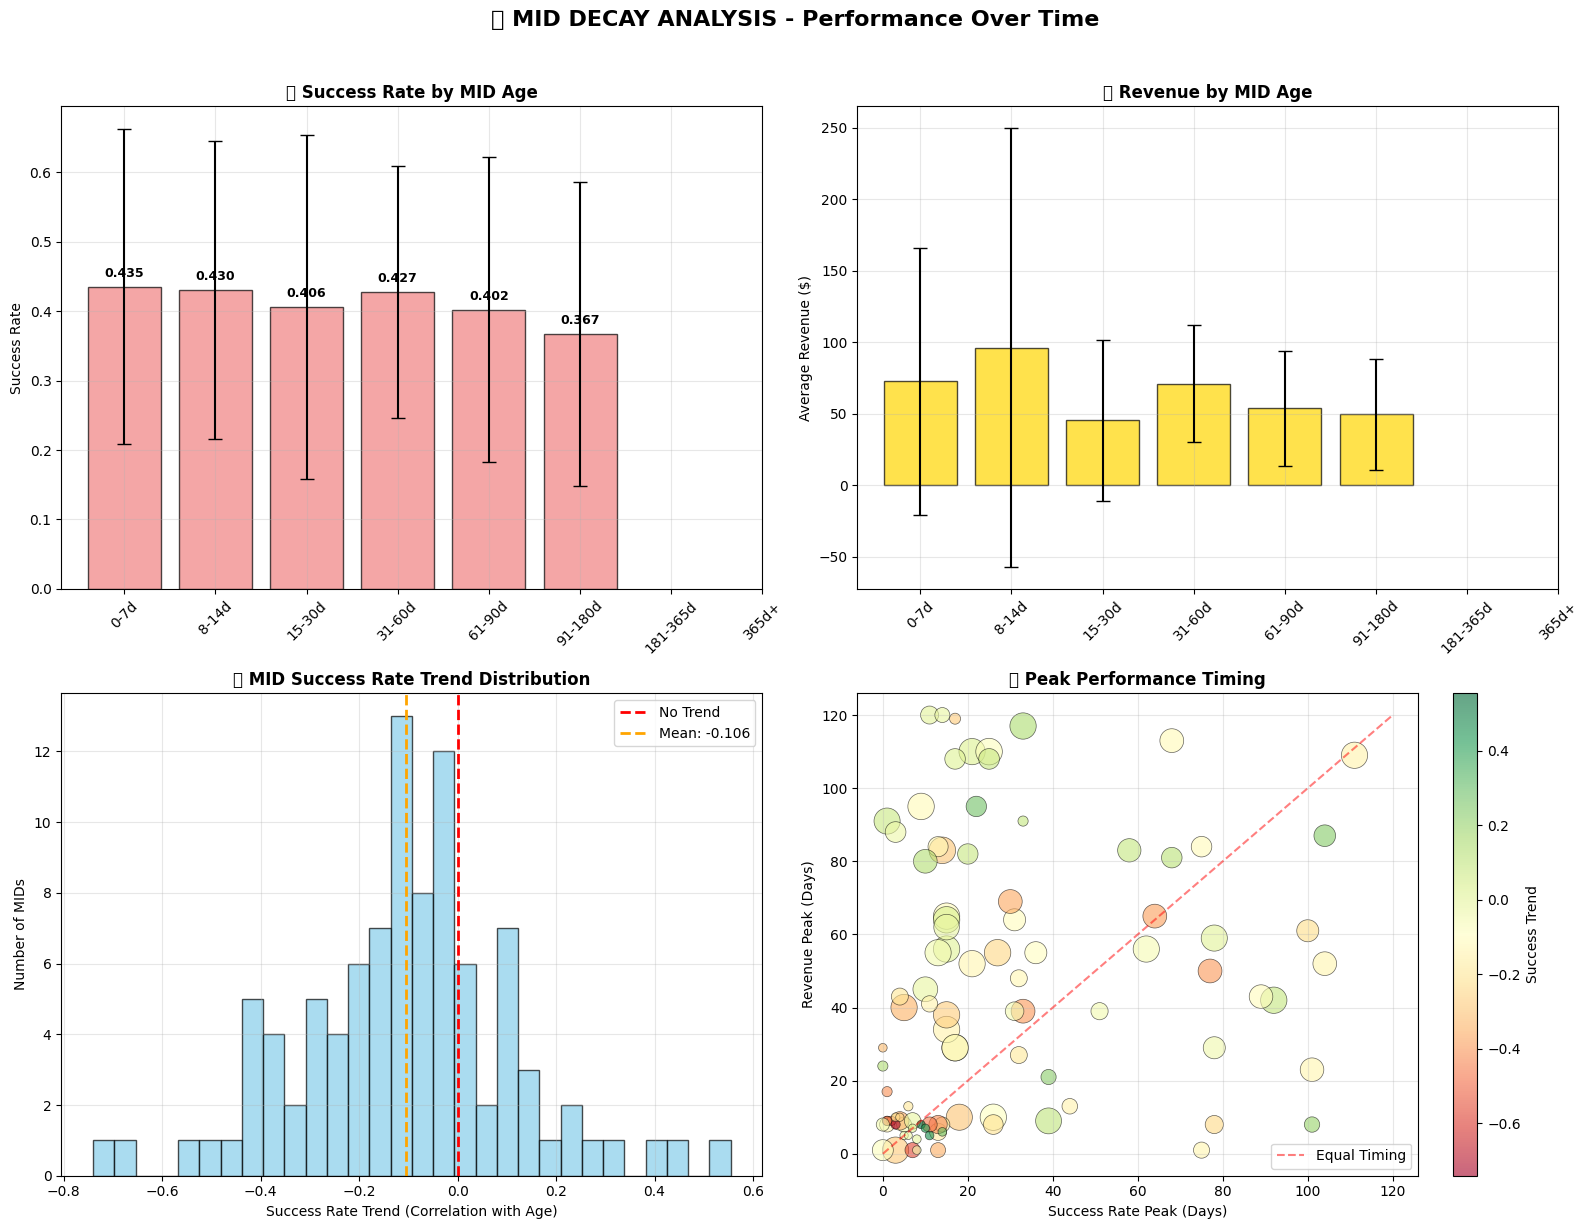


🎯 KEY DECAY INSIGHTS:
--------------------------------------------------
• 63.9% of MIDs show significant decline patterns
• Success rates peak around day 28
• Revenue peaks around day 43
• Steepest decline occurs in 91-180d period (-0.035 drop)
• Average success variance: 0.0518
• High variance MIDs (>0.05): 30

💡 RECOMMENDATIONS:
• Monitor MIDs closely after their peak performance period
• Consider refreshing/rotating MIDs showing decline trends
• Investigate what causes performance peaks to optimize timing
• Focus on MIDs with high variance - they may need attention
⏰ LAG CORRELATION ANALYSIS (1-30 Days)
Testing 14 variables with lags 1-30 days...

Original correlations vs best lag correlations:
--------------------------------------------------------------------------------
processing_fees_rate           | Orig:  0.8880 | Best:  0.8880 (lag  0) | 📉 UNCHANGED
net_revenue                    | Orig:  0.2832 | Best:  0.2832 (lag  0) | 📉 UNCHANGED
adjustment_rate                | Orig:

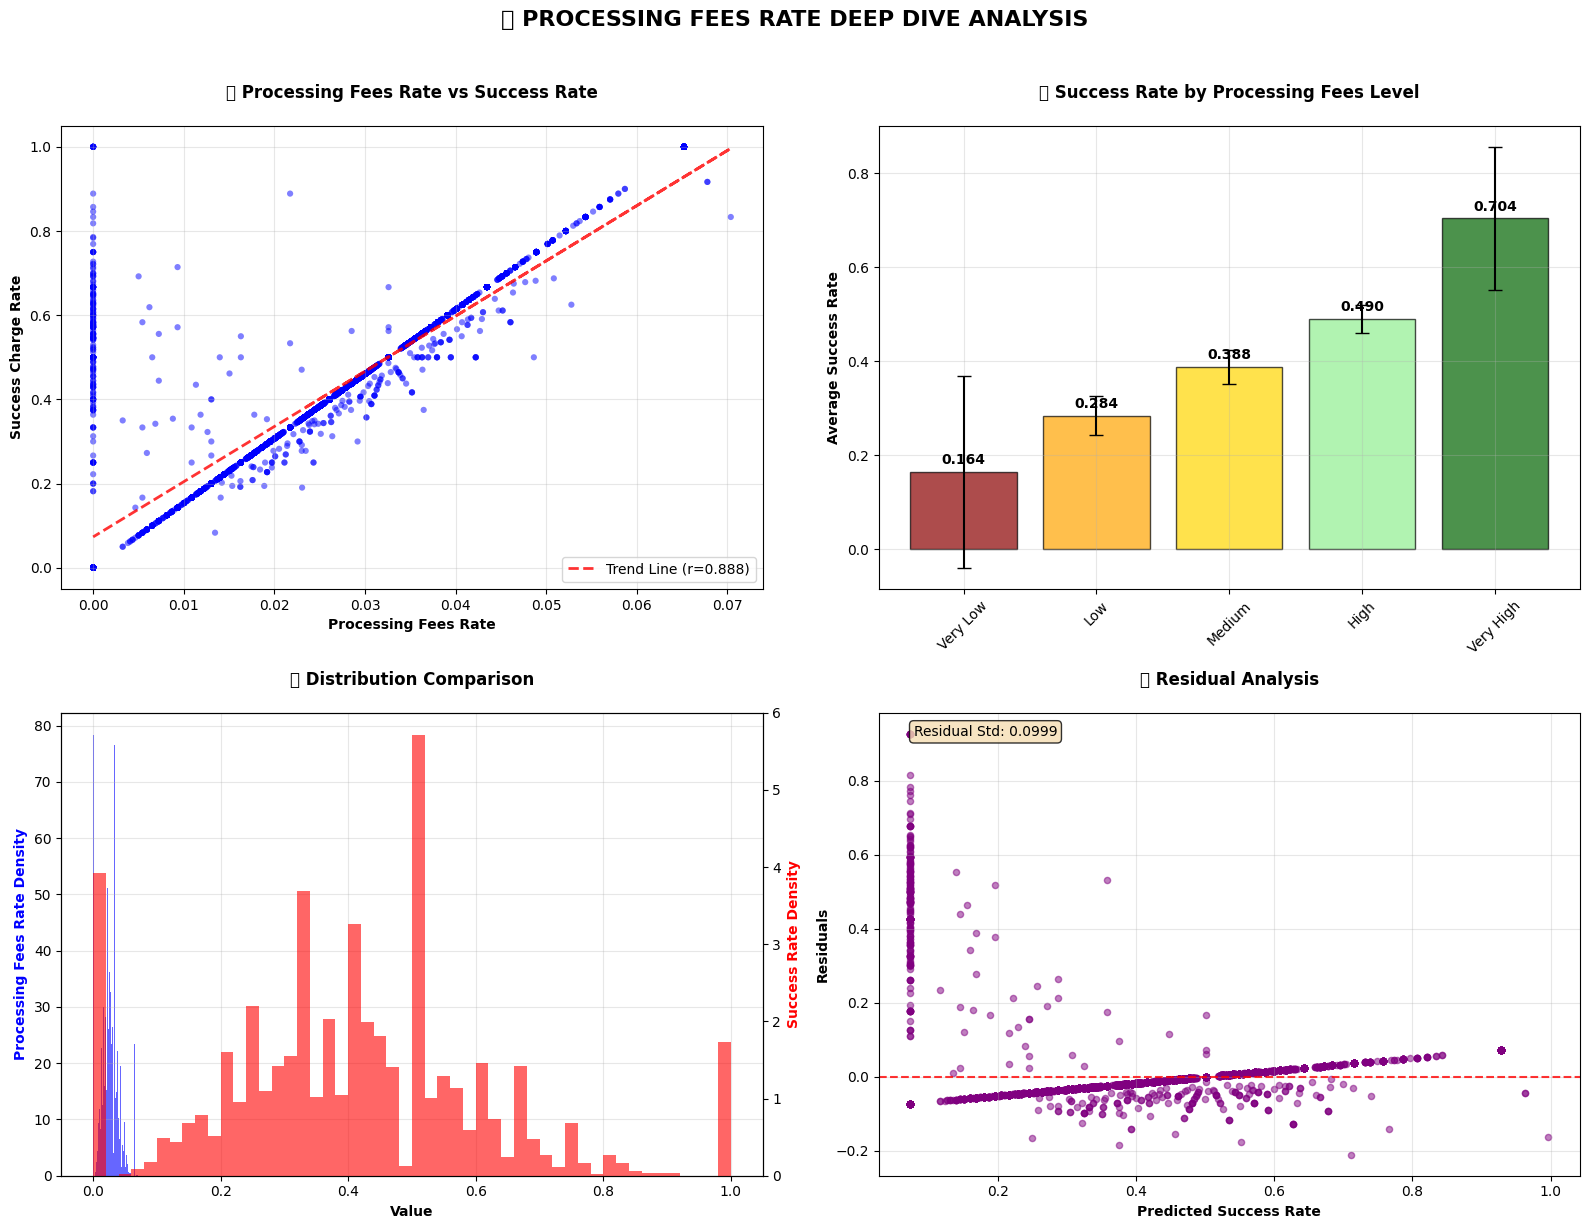


🎯 KEY INSIGHTS:
--------------------------------------------------
• R-squared: 0.7886 (78.9% of variance explained)
• Effect Size: Very Large Effect
• Max Success Rate Impact: 0.923 across full fees range
• Processing fees outliers: 232 (3.4%)

💡 BUSINESS IMPLICATIONS:
--------------------------------------------------
• Higher processing fees are strongly associated with higher success rates
• This suggests premium processors/routes have better approval rates
• Consider cost-benefit analysis: higher fees vs higher success rates
• May indicate that 'you get what you pay for' in payment processing
• Could guide pricing strategy and processor selection decisions
• Monitor if this relationship holds across different affiliates/products

🔍 BY AFFILIATE ANALYSIS:
------------------------------
Affiliate 1: Correlation = 0.8657
Affiliate 15: Correlation = 0.9963

🎯 OPTIMAL PERFORMANCE:
• Best performing fees level: Very High
• Success rate at optimal level: 0.7041


In [8]:
# Import all functions and objects from MID_Modeling.ipynb
%run MID_Modeling.ipynb

In [9]:
# Additional imports for this analysis
import warnings
warnings.filterwarnings('ignore')

print("✅ Successfully imported data from MID_Modeling.ipynb")
print(f"Dataset shape: {pooled_df.shape}")
print(f"Date range: {pooled_df['date'].min()} to {pooled_df['date'].max()}")

✅ Successfully imported data from MID_Modeling.ipynb
Dataset shape: (6816, 140)
Date range: 2025-06-02 00:00:00 to 2025-10-02 00:00:00


## 1. BIN-BASED ROUTING ANALYSIS




**Objective**: Identify which processors perform best for specific Card BIN numbers

**Key Questions**:
- Do certain BINs have significantly better approval rates on specific processors?
- What is the volume distribution across BIN × Processor combinations?
- Can we build a routing recommendation matrix?

### 1.1) **Optimal Issuers - 50 (via elbow method)**


In [10]:
count = 0
for column in all_df.columns:
    if "bankissuer" in column:
        count+= 1
print(count)

50


In [11]:
p_aff1 = pooled_df[pooled_df["affiliate_id"] == 1]
p_aff15 = pooled_df[pooled_df["affiliate_id"] == 15]

### 1.2) **Analysis of approvals for each BIN - Affiliate based**


#### 1.2.1) **Affiliate ID: 1**


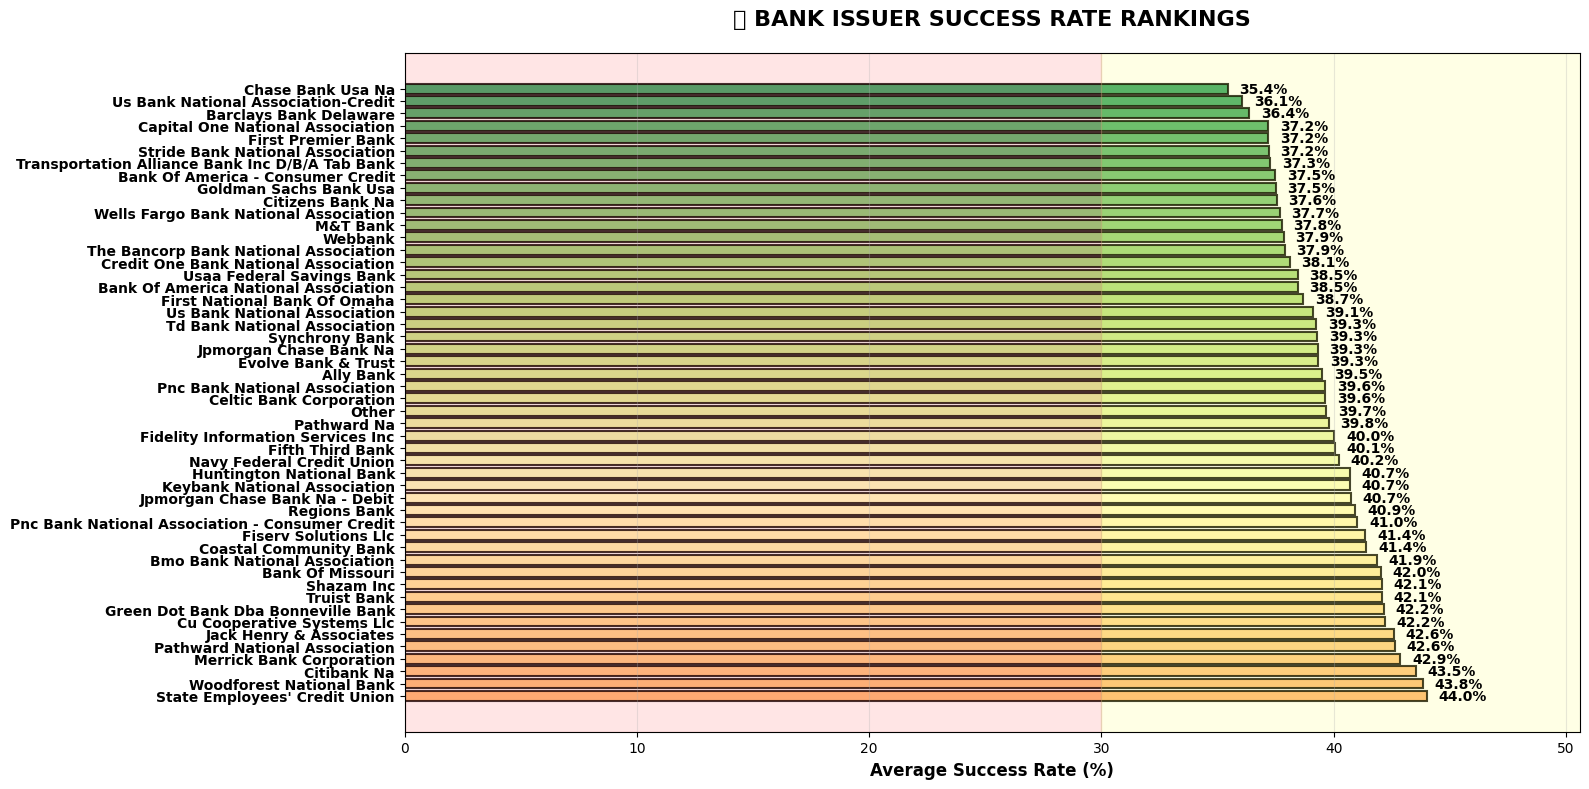


🏦 BANK ISSUER PERFORMANCE ANALYSIS

🥇 TOP 5 PERFORMING BANK ISSUERS:
   1. State Employees' Credit Union            | Success: 44.0% | Volume: 5,225 | Revenue: $30,369
   2. Woodforest National Bank                 | Success: 43.8% | Volume: 5,922 | Revenue: $34,764
   3. Citibank Na                              | Success: 43.5% | Volume: 23,106 | Revenue: $129,196
   4. Merrick Bank Corporation                 | Success: 42.9% | Volume: 4,958 | Revenue: $27,520
   5. Pathward National Association            | Success: 42.6% | Volume: 5,702 | Revenue: $32,057

🥉 BOTTOM 5 PERFORMING BANK ISSUERS:
   1. First Premier Bank                       | Success: 37.2% | Volume: 4,557 | Revenue: $23,176
   2. Capital One National Association         | Success: 37.2% | Volume: 42,339 | Revenue: $213,613
   3. Barclays Bank Delaware                   | Success: 36.4% | Volume: 9,889 | Revenue: $52,527
   4. Us Bank National Association-Credit      | Success: 36.1% | Volume: 19,823 | Revenue: $101,

In [12]:
# Bank Issuer Success Rate Analysis
import matplotlib.pyplot as plt
import numpy as np

# Bank issuer columns
bank_issuers = [col for col in p_aff1.columns if col.startswith('bankissuer_')]

# Calculate success rates for each bank issuer
bank_performance = {}
for bank in bank_issuers:
    if bank in p_aff1.columns:
        # Get data where this bank issuer was used
        bank_data = p_aff1[p_aff1[bank] == 1]
        if len(bank_data) > 0:
            avg_success = bank_data['success_charge_ratess'].mean()
            total_volume = bank_data['attempted_charges'].sum()
            total_revenue = bank_data['gross_product_revenue'].sum()
            bank_name = bank.replace('bankissuer_', '').replace('_', ' ').title()
            bank_performance[bank_name] = {
                'success_rate': avg_success * 100,
                'volume': total_volume,
                'revenue': total_revenue
            }

# Sort by success rate
sorted_banks = sorted(bank_performance.items(), key=lambda x: x[1]['success_rate'], reverse=True)

# Create the visualization
fig, ax = plt.subplots(figsize=(16, 8))

# Create gradient colors
banks = [b[0] for b in sorted_banks]
rates = [b[1]['success_rate'] for b in sorted_banks]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_banks)))

bars = ax.barh(range(len(banks)), rates, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, rates)):
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', ha='left', va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(banks)))
ax.set_yticklabels(banks, fontweight='bold')
ax.set_xlabel('Average Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('🏦 BANK ISSUER SUCCESS RATE RANKINGS', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, max(rates) * 1.15)

# Add performance zones
ax.axvspan(0, 30, alpha=0.1, color='red', label='Poor')
ax.axvspan(30, 60, alpha=0.1, color='yellow', label='Average')  
ax.axvspan(60, 100, alpha=0.1, color='green', label='Excellent')

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*80)
print("🏦 BANK ISSUER PERFORMANCE ANALYSIS")
print("="*80)

print(f"\n🥇 TOP 5 PERFORMING BANK ISSUERS:")
for i, (bank, stats) in enumerate(sorted_banks[:5], 1):
    print(f"   {i}. {bank:<40} | Success: {stats['success_rate']:.1f}% | Volume: {stats['volume']:,} | Revenue: ${stats['revenue']:,.0f}")

print(f"\n🥉 BOTTOM 5 PERFORMING BANK ISSUERS:")
for i, (bank, stats) in enumerate(sorted_banks[-5:], 1):
    print(f"   {i}. {bank:<40} | Success: {stats['success_rate']:.1f}% | Volume: {stats['volume']:,} | Revenue: ${stats['revenue']:,.0f}")

# Summary statistics
avg_success = np.mean(rates)
print(f"\n📊 OVERALL STATISTICS:")
print(f"Average success rate across all issuers: {avg_success:.1f}%")
print(f"Best performing issuer: {max(rates):.1f}%")
print(f"Worst performing issuer: {min(rates):.1f}%")
print(f"Performance range: {max(rates) - min(rates):.1f}%")

# Volume analysis
total_volume = sum([stats['volume'] for _, stats in sorted_banks])
print(f"\nTop 3 by volume:")
volume_sorted = sorted(bank_performance.items(), key=lambda x: x[1]['volume'], reverse=True)
for i, (bank, stats) in enumerate(volume_sorted[:3], 1):
    volume_share = (stats['volume'] / total_volume) * 100
    print(f"   {i}. {bank:<40} | Volume: {stats['volume']:,} ({volume_share:.1f}% of total)")

### 1.3) **Comparative Bank Issuer Analysis: Affiliate 1 vs Affiliate 15**

In [13]:
# COMPREHENSIVE BANK ISSUER COMPARISON: AFFILIATE 1 vs 15
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Bank issuer columns
bank_issuers = [col for col in pooled_df.columns if col.startswith('bankissuer_')]

print("="*100)
print("🏦 COMPREHENSIVE BANK ISSUER PERFORMANCE COMPARISON: AFFILIATE 1 vs AFFILIATE 15")
print("="*100)

# ==========================================
# PART 1: CALCULATE PERFORMANCE FOR EACH AFFILIATE
# ==========================================

def calculate_issuer_performance(df, affiliate_name):
    """Calculate performance metrics for each bank issuer"""
    performance = {}
    for bank in bank_issuers:
        if bank in df.columns:
            bank_data = df[df[bank] == 1]
            if len(bank_data) > 0:
                bank_name = bank.replace('bankissuer_', '').replace('_', ' ').title()
                performance[bank_name] = {
                    'success_rate': bank_data['success_charge_ratess'].mean() * 100,
                    'volume': bank_data['attempted_charges'].sum(),
                    'revenue': bank_data['gross_product_revenue'].sum(),
                    'avg_revenue_per_txn': bank_data['gross_product_revenue'].sum() / max(bank_data['attempted_charges'].sum(), 1),
                    'num_transactions': len(bank_data),
                    'declined_rate': bank_data['declined_charge_ratess'].mean() * 100,
                    'total_successful': bank_data['successful_charges'].sum(),
                    'total_declined': bank_data['declined_charges'].sum()
                }
    return performance

# Calculate for both affiliates
perf_aff1 = calculate_issuer_performance(p_aff1, 'Affiliate 1')
perf_aff15 = calculate_issuer_performance(p_aff15, 'Affiliate 15')

# Get common bank issuers (that appear in both affiliates)
banks_aff1 = set(perf_aff1.keys())
banks_aff15 = set(perf_aff15.keys())
common_banks = banks_aff1 & banks_aff15
aff1_only = banks_aff1 - banks_aff15
aff15_only = banks_aff15 - banks_aff1

print(f"\n📊 DATASET OVERVIEW:")
print(f"   Affiliate 1 transactions: {len(p_aff1):,}")
print(f"   Affiliate 15 transactions: {len(p_aff15):,}")
print(f"   Total bank issuers in Aff1: {len(banks_aff1)}")
print(f"   Total bank issuers in Aff15: {len(banks_aff15)}")
print(f"   Common bank issuers: {len(common_banks)}")
print(f"   Aff1 exclusive issuers: {len(aff1_only)}")
print(f"   Aff15 exclusive issuers: {len(aff15_only)}")

# ==========================================
# PART 2: COMPARATIVE ANALYSIS FOR COMMON BANKS
# ==========================================

print(f"\n" + "="*100)
print(f"🔍 DETAILED COMPARISON FOR COMMON BANK ISSUERS (n={len(common_banks)})")
print("="*100)

# Build comparison dataframe
comparison_data = []
for bank in common_banks:
    aff1_stats = perf_aff1[bank]
    aff15_stats = perf_aff15[bank]
    
    success_diff = aff1_stats['success_rate'] - aff15_stats['success_rate']
    volume_ratio = aff1_stats['volume'] / max(aff15_stats['volume'], 1)
    
    comparison_data.append({
        'bank': bank,
        'aff1_success': aff1_stats['success_rate'],
        'aff15_success': aff15_stats['success_rate'],
        'success_diff': success_diff,
        'success_diff_pct': (success_diff / max(aff15_stats['success_rate'], 0.01)) * 100,
        'aff1_volume': aff1_stats['volume'],
        'aff15_volume': aff15_stats['volume'],
        'volume_ratio': volume_ratio,
        'aff1_revenue': aff1_stats['revenue'],
        'aff15_revenue': aff15_stats['revenue'],
        'aff1_avg_rev_per_txn': aff1_stats['avg_revenue_per_txn'],
        'aff15_avg_rev_per_txn': aff15_stats['avg_revenue_per_txn'],
        'combined_volume': aff1_stats['volume'] + aff15_stats['volume']
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort by combined volume (most important issuers first)
comparison_df = comparison_df.sort_values('combined_volume', ascending=False)

# ==========================================
# PART 3: KEY FINDINGS - SUCCESS RATE DIFFERENCES
# ==========================================

print(f"\n🎯 TOP 10 SUCCESS RATE DIFFERENCES (Aff1 - Aff15):")
print(f"{'Bank Issuer':<45} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Diff':>10} {'Diff %':>10} {'Combined Vol':>15}")
print("-" * 100)

top_10_by_volume = comparison_df.head(10)
for _, row in top_10_by_volume.iterrows():
    diff_indicator = "✅" if row['success_diff'] > 0 else "❌"
    print(f"{row['bank']:<45} {row['aff1_success']:>9.2f}% {row['aff15_success']:>9.2f}% {row['success_diff']:>9.2f}% {row['success_diff_pct']:>9.1f}% {row['combined_volume']:>14,} {diff_indicator}")

# Biggest winners and losers for Aff1
print(f"\n🏆 TOP 5 ISSUERS WHERE AFF1 SIGNIFICANTLY OUTPERFORMS AFF15:")
aff1_winners = comparison_df.nlargest(5, 'success_diff')
for i, (_, row) in enumerate(aff1_winners.iterrows(), 1):
    print(f"   {i}. {row['bank']:<40} | Aff1: {row['aff1_success']:.2f}% | Aff15: {row['aff15_success']:.2f}% | Δ: +{row['success_diff']:.2f}% | Vol: {row['combined_volume']:,}")

print(f"\n⚠️ TOP 5 ISSUERS WHERE AFF15 SIGNIFICANTLY OUTPERFORMS AFF1:")
aff15_winners = comparison_df.nsmallest(5, 'success_diff')
for i, (_, row) in enumerate(aff15_winners.iterrows(), 1):
    print(f"   {i}. {row['bank']:<40} | Aff1: {row['aff1_success']:.2f}% | Aff15: {row['aff15_success']:.2f}% | Δ: {row['success_diff']:.2f}% | Vol: {row['combined_volume']:,}")

# ==========================================
# PART 4: VOLUME DISTRIBUTION ANALYSIS
# ==========================================

print(f"\n" + "="*100)
print(f"📈 VOLUME DISTRIBUTION ANALYSIS")
print("="*100)

total_vol_aff1 = comparison_df['aff1_volume'].sum()
total_vol_aff15 = comparison_df['aff15_volume'].sum()

print(f"\nTotal attempted charges (common issuers):")
print(f"   Affiliate 1: {total_vol_aff1:,}")
print(f"   Affiliate 15: {total_vol_aff15:,}")
print(f"   Ratio (Aff1/Aff15): {total_vol_aff1/max(total_vol_aff15, 1):.2f}x")

# Top issuers by volume for each affiliate
print(f"\n🔝 TOP 10 BANK ISSUERS BY VOLUME - AFFILIATE 1:")
aff1_sorted = comparison_df.nlargest(10, 'aff1_volume')
for i, (_, row) in enumerate(aff1_sorted.iterrows(), 1):
    pct = (row['aff1_volume'] / total_vol_aff1) * 100
    print(f"   {i:2d}. {row['bank']:<40} | Volume: {row['aff1_volume']:>8,} ({pct:>5.1f}%) | SR: {row['aff1_success']:>6.2f}%")

print(f"\n🔝 TOP 10 BANK ISSUERS BY VOLUME - AFFILIATE 15:")
aff15_sorted = comparison_df.nlargest(10, 'aff15_volume')
for i, (_, row) in enumerate(aff15_sorted.iterrows(), 1):
    pct = (row['aff15_volume'] / total_vol_aff15) * 100
    print(f"   {i:2d}. {row['bank']:<40} | Volume: {row['aff15_volume']:>8,} ({pct:>5.1f}%) | SR: {row['aff15_success']:>6.2f}%")

# ==========================================
# PART 5: STATISTICAL SUMMARY
# ==========================================

print(f"\n" + "="*100)
print(f"📊 STATISTICAL SUMMARY")
print("="*100)

# Overall statistics
aff1_avg_success = comparison_df['aff1_success'].mean()
aff15_avg_success = comparison_df['aff15_success'].mean()
aff1_weighted_success = (comparison_df['aff1_success'] * comparison_df['aff1_volume']).sum() / total_vol_aff1
aff15_weighted_success = (comparison_df['aff15_success'] * comparison_df['aff15_volume']).sum() / total_vol_aff15

print(f"\n🎲 AVERAGE SUCCESS RATES (across all common issuers):")
print(f"   Affiliate 1 (simple avg): {aff1_avg_success:.2f}%")
print(f"   Affiliate 15 (simple avg): {aff15_avg_success:.2f}%")
print(f"   Difference: {aff1_avg_success - aff15_avg_success:+.2f}%")

print(f"\n⚖️ WEIGHTED AVERAGE SUCCESS RATES (volume-weighted):")
print(f"   Affiliate 1 (weighted): {aff1_weighted_success:.2f}%")
print(f"   Affiliate 15 (weighted): {aff15_weighted_success:.2f}%")
print(f"   Difference: {aff1_weighted_success - aff15_weighted_success:+.2f}%")

# Distribution statistics
print(f"\n📉 SUCCESS RATE VARIANCE:")
print(f"   Affiliate 1 std dev: {comparison_df['aff1_success'].std():.2f}%")
print(f"   Affiliate 15 std dev: {comparison_df['aff15_success'].std():.2f}%")
print(f"   Aff1 range: {comparison_df['aff1_success'].min():.2f}% - {comparison_df['aff1_success'].max():.2f}%")
print(f"   Aff15 range: {comparison_df['aff15_success'].min():.2f}% - {comparison_df['aff15_success'].max():.2f}%")

# Count issuers by performance category
aff1_better_count = (comparison_df['success_diff'] > 0).sum()
aff15_better_count = (comparison_df['success_diff'] < 0).sum()
equal_count = (comparison_df['success_diff'] == 0).sum()

print(f"\n🏁 PERFORMANCE DISTRIBUTION:")
print(f"   Issuers where Aff1 performs better: {aff1_better_count} ({aff1_better_count/len(comparison_df)*100:.1f}%)")
print(f"   Issuers where Aff15 performs better: {aff15_better_count} ({aff15_better_count/len(comparison_df)*100:.1f}%)")
print(f"   Issuers with equal performance: {equal_count}")

# ==========================================
# PART 6: EXCLUSIVE ISSUERS ANALYSIS
# ==========================================

if aff1_only or aff15_only:
    print(f"\n" + "="*100)
    print(f"🔐 EXCLUSIVE BANK ISSUERS ANALYSIS")
    print("="*100)
    
    if aff1_only:
        print(f"\n📌 AFFILIATE 1 EXCLUSIVE ISSUERS ({len(aff1_only)}):")
        aff1_exclusive_data = [(bank, perf_aff1[bank]) for bank in aff1_only]
        aff1_exclusive_sorted = sorted(aff1_exclusive_data, key=lambda x: x[1]['volume'], reverse=True)[:10]
        for i, (bank, stats) in enumerate(aff1_exclusive_sorted, 1):
            print(f"   {i:2d}. {bank:<40} | SR: {stats['success_rate']:>6.2f}% | Vol: {stats['volume']:>8,} | Rev: ${stats['revenue']:>12,.0f}")
    
    if aff15_only:
        print(f"\n📌 AFFILIATE 15 EXCLUSIVE ISSUERS ({len(aff15_only)}):")
        aff15_exclusive_data = [(bank, perf_aff15[bank]) for bank in aff15_only]
        aff15_exclusive_sorted = sorted(aff15_exclusive_data, key=lambda x: x[1]['volume'], reverse=True)[:10]
        for i, (bank, stats) in enumerate(aff15_exclusive_sorted, 1):
            print(f"   {i:2d}. {bank:<40} | SR: {stats['success_rate']:>6.2f}% | Vol: {stats['volume']:>8,} | Rev: ${stats['revenue']:>12,.0f}")

print(f"\n" + "="*100)
print(f"✅ Analysis Complete!")
print("="*100)

🏦 COMPREHENSIVE BANK ISSUER PERFORMANCE COMPARISON: AFFILIATE 1 vs AFFILIATE 15

📊 DATASET OVERVIEW:
   Affiliate 1 transactions: 5,196
   Affiliate 15 transactions: 1,620
   Total bank issuers in Aff1: 50
   Total bank issuers in Aff15: 50
   Common bank issuers: 50
   Aff1 exclusive issuers: 0
   Aff15 exclusive issuers: 0

🔍 DETAILED COMPARISON FOR COMMON BANK ISSUERS (n=50)

🎯 TOP 10 SUCCESS RATE DIFFERENCES (Aff1 - Aff15):
Bank Issuer                                      Aff1 SR   Aff15 SR       Diff     Diff %    Combined Vol
----------------------------------------------------------------------------------------------------
Other                                             39.68%     44.72%     -5.04%     -11.3%         75,799 ❌
Capital One National Association                  37.17%     42.47%     -5.29%     -12.5%         56,330 ❌
Jpmorgan Chase Bank Na                            39.32%     45.21%     -5.90%     -13.0%         48,886 ❌
Wells Fargo Bank National Association   

In [14]:
# Export pooled_df to Excel
pooled_df.to_excel("pooled_df.xlsx", index=False)

# Also assign pooled_df to pooled<-df (R-style variable name, as a string for reference)
pooled_df_alias = pooled_df  # Python does not support '<-' in variable names, so use an alias


## 2. AFFILIATE × ISSUER × PROCESSOR ROUTING ANALYSIS

**Objective**: Identify if certain processors perform better for specific Bank Issuers on different affiliates

This analysis will reveal if we can optimize routing by directing specific Affiliate+Issuer combinations to better-performing processors.

In [15]:
# STEP 1: Build Affiliate × Issuer × Processor Performance Matrix
import pandas as pd
import numpy as np

# Get all bank issuer and processor columns
bank_issuer_cols = [col for col in pooled_df.columns if col.startswith('bankissuer_')]
processor_cols = [col for col in pooled_df.columns if col.startswith('processor_')]

print(f"Total Bank Issuers: {len(bank_issuer_cols)}")
print(f"Total Processors: {len(processor_cols)}")

# Function to get active issuer and processor for each row
def get_active_column(row, col_list):
    """Return the name of the active (value=1) column from a list"""
    for col in col_list:
        if col in row.index and row[col] == 1:
            return col.replace('bankissuer_', '').replace('processor_', '').replace('_', ' ').title()
    return 'Unknown'

# Add issuer and processor names to dataframe
pooled_df['issuer_name'] = pooled_df.apply(lambda row: get_active_column(row, bank_issuer_cols), axis=1)
pooled_df['processor_name'] = pooled_df.apply(lambda row: get_active_column(row, processor_cols), axis=1)

print("\n✅ Added issuer_name and processor_name columns to pooled_df")
print(f"Unique issuers: {pooled_df['issuer_name'].nunique()}")
print(f"Unique processors: {pooled_df['processor_name'].nunique()}")

Total Bank Issuers: 50
Total Processors: 22

✅ Added issuer_name and processor_name columns to pooled_df
Unique issuers: 49
Unique processors: 22


In [16]:
# STEP 2: Create Comparison DataFrame - Affiliate × Issuer × Processor
print("="*100)
print("🔄 BUILDING AFFILIATE × ISSUER × PROCESSOR COMPARISON")
print("="*100)

# Group by affiliate, issuer, and processor
routing_analysis = []

for issuer in pooled_df['issuer_name'].unique():
    if issuer == 'Unknown':
        continue
        
    for processor in pooled_df['processor_name'].unique():
        if processor == 'Unknown':
            continue
        
        # Filter for this issuer × processor combination
        combo_data = pooled_df[(pooled_df['issuer_name'] == issuer) & 
                               (pooled_df['processor_name'] == processor)]
        
        if len(combo_data) == 0:
            continue
        
        # Split by affiliate
        aff1_data = combo_data[combo_data['affiliate_id'] == 1]
        aff15_data = combo_data[combo_data['affiliate_id'] == 15]
        
        # Only include if both affiliates have data for this combo
        if len(aff1_data) > 0 and len(aff15_data) > 0:
            aff1_sr = aff1_data['success_charge_ratess'].mean() * 100
            aff15_sr = aff15_data['success_charge_ratess'].mean() * 100
            aff1_vol = aff1_data['attempted_charges'].sum()
            aff15_vol = aff15_data['attempted_charges'].sum()
            
            routing_analysis.append({
                'issuer': issuer,
                'processor': processor,
                'aff1_approval_rate': aff1_sr,
                'aff15_approval_rate': aff15_sr,
                'aff1_volume': aff1_vol,
                'aff15_volume': aff15_vol,
                'total_volume': aff1_vol + aff15_vol,
                'approval_gap': aff15_sr - aff1_sr,  # Positive = Aff15 better
                'approval_gap_pct': ((aff15_sr - aff1_sr) / max(aff1_sr, 0.01)) * 100,
                'aff1_revenue': aff1_data['gross_product_revenue'].sum(),
                'aff15_revenue': aff15_data['gross_product_revenue'].sum()
            })

# Create DataFrame
routing_df = pd.DataFrame(routing_analysis)

# Sort by total volume (most important combinations first)
routing_df = routing_df.sort_values('total_volume', ascending=False)

print(f"\n✅ Created routing analysis with {len(routing_df)} Issuer × Processor combinations")
print(f"   (combinations that exist in BOTH affiliates)")
print(f"\nTotal volume covered: {routing_df['total_volume'].sum():,} transactions")
print(f"Coverage: {routing_df['total_volume'].sum() / pooled_df['attempted_charges'].sum() * 100:.1f}% of all transactions")

# Display summary
routing_df.head(20)

🔄 BUILDING AFFILIATE × ISSUER × PROCESSOR COMPARISON

✅ Created routing analysis with 217 Issuer × Processor combinations
   (combinations that exist in BOTH affiliates)

Total volume covered: 73,191 transactions
Coverage: 93.5% of all transactions


,issuer,processor,aff1_approval_rate,aff15_approval_rate,aff1_volume,aff15_volume,total_volume,approval_gap,approval_gap_pct,aff1_revenue,aff15_revenue
0,Stride Bank National Association,Net Esq,34.564402,41.558410,2557,1853,4410,6.994008,20.234713,11484.99,9770.62
30,Bank Of America National Association,Net Esq,35.332029,45.165255,2612,1249,3861,9.833226,27.830911,11974.81,7050.83
66,Barclays Bank Delaware,Quant Cbsl,44.174326,44.633430,3426,92,3518,0.459104,1.039301,23214.89,541.38
15,Jpmorgan Chase Bank Na,Net Esq,37.396470,45.693145,2222,767,2989,8.296676,22.185718,10660.03,4447.05
59,Barclays Bank Delaware,Net Esq,33.698491,42.937657,1736,416,2152,9.239165,27.417148,7321.52,2255.75
7,Stride Bank National Association,Quant Cbsl,38.602388,43.053515,1604,246,1850,4.451127,11.530704,9371.03,1405.01
34,Bank Of America National Association,Prior Syn,35.503796,48.393283,1337,386,1723,12.889487,36.304531,5761.83,2384.65
4,Stride Bank National Association,Prior Syn,32.957592,42.185481,1128,459,1587,9.227889,27.999283,4769.30,2358.87
139,Synchrony Bank,Net Esq,36.387051,35.922385,1319,241,1560,-0.464666,-1.277009,6071.19,1134.32
19,Jpmorgan Chase Bank Na,Prior Syn,37.205574,45.664668,1119,321,1440,8.459094,22.736093,5362.24,1830.38


In [17]:
# STEP 3: Detailed Analysis - Top Combinations by Volume
print("="*120)
print("🎯 TOP 20 ISSUER × PROCESSOR COMBINATIONS (by Volume)")
print("="*120)
print(f"{'Issuer':<35} {'Processor':<20} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Gap':>8} {'Aff1 Vol':>10} {'Aff15 Vol':>10} {'Total':>10}")
print("-"*120)

for idx, row in routing_df.head(20).iterrows():
    gap_str = f"{row['approval_gap']:+.2f}%"
    indicator = "✅" if abs(row['approval_gap']) < 2 else ("🟡" if abs(row['approval_gap']) < 5 else "🔴")
    
    print(f"{row['issuer']:<35} {row['processor']:<20} "
          f"{row['aff1_approval_rate']:>9.2f}% {row['aff15_approval_rate']:>9.2f}% "
          f"{gap_str:>8} {row['aff1_volume']:>10,} {row['aff15_volume']:>10,} "
          f"{row['total_volume']:>10,} {indicator}")

print("\n" + "="*120)
print("Legend: ✅ <2% gap (similar) | 🟡 2-5% gap (moderate) | 🔴 >5% gap (significant)")
print("="*120)

🎯 TOP 20 ISSUER × PROCESSOR COMBINATIONS (by Volume)
Issuer                              Processor               Aff1 SR   Aff15 SR      Gap   Aff1 Vol  Aff15 Vol      Total
------------------------------------------------------------------------------------------------------------------------
Stride Bank National Association    Net Esq                  34.56%     41.56%   +6.99%      2,557      1,853      4,410 🔴
Bank Of America National Association Net Esq                  35.33%     45.17%   +9.83%      2,612      1,249      3,861 🔴
Barclays Bank Delaware              Quant Cbsl               44.17%     44.63%   +0.46%      3,426         92      3,518 ✅
Jpmorgan Chase Bank Na              Net Esq                  37.40%     45.69%   +8.30%      2,222        767      2,989 🔴
Barclays Bank Delaware              Net Esq                  33.70%     42.94%   +9.24%      1,736        416      2,152 🔴
Stride Bank National Association    Quant Cbsl               38.60%     43.05%   +4.45%  

In [18]:
# STEP 4: Focus on High-Volume, High-Gap Combinations
print("\n" + "="*120)
print("🔥 BIGGEST ROUTING OPPORTUNITIES (High Volume + Large Gap)")
print("="*120)

# Filter for combinations with meaningful volume and significant gaps
min_volume = 1000  # At least 1,000 total transactions
min_gap = 3.0      # At least 3pp difference

opportunities = routing_df[
    (routing_df['total_volume'] >= min_volume) & 
    (abs(routing_df['approval_gap']) >= min_gap)
].sort_values('approval_gap', ascending=False)

print(f"\nFound {len(opportunities)} routing opportunities (volume ≥ {min_volume:,}, gap ≥ {min_gap}%)")
print(f"\n{'Issuer':<35} {'Processor':<20} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Gap':>8} {'Total Vol':>10} {'Winner':>10}")
print("-"*120)

for idx, row in opportunities.iterrows():
    winner = "Aff15 ✅" if row['approval_gap'] > 0 else "Aff1 ✅"
    print(f"{row['issuer']:<35} {row['processor']:<20} "
          f"{row['aff1_approval_rate']:>9.2f}% {row['aff15_approval_rate']:>9.2f}% "
          f"{row['approval_gap']:>+7.2f}% {row['total_volume']:>10,} {winner:>10}")

# Calculate potential impact
if len(opportunities) > 0:
    total_opportunity_volume = opportunities['total_volume'].sum()
    avg_gap = opportunities['approval_gap'].mean()
    
    print(f"\n📊 POTENTIAL IMPACT:")
    print(f"   Total volume in these opportunities: {total_opportunity_volume:,} transactions")
    print(f"   Average approval gap: {avg_gap:+.2f}%")
    print(f"   If we could replicate Aff15's performance on Aff1:")
    print(f"   → Potential additional approvals: ~{int(total_opportunity_volume * 0.76 * abs(avg_gap) / 100):,} transactions")
else:
    print("\nNo significant routing opportunities found with current filters.")


🔥 BIGGEST ROUTING OPPORTUNITIES (High Volume + Large Gap)

Found 16 routing opportunities (volume ≥ 1,000, gap ≥ 3.0%)

Issuer                              Processor               Aff1 SR   Aff15 SR      Gap  Total Vol     Winner
------------------------------------------------------------------------------------------------------------------------
Bank Of America National Association Apps                     31.31%     50.34%  +19.03%      1,053    Aff15 ✅
Woodforest National Bank            Net Esq                  37.15%     52.16%  +15.01%      1,282    Aff15 ✅
Bank Of America National Association Prior Syn                35.50%     48.39%  +12.89%      1,723    Aff15 ✅
Bank Of America National Association Net Esq                  35.33%     45.17%   +9.83%      3,861    Aff15 ✅
Barclays Bank Delaware              Net Esq                  33.70%     42.94%   +9.24%      2,152    Aff15 ✅
Stride Bank National Association    Prior Syn                32.96%     42.19%   +9.23%      1,

In [19]:
# STEP 5: Processor Performance Breakdown by Issuer
print("\n" + "="*120)
print("📊 PROCESSOR PERFORMANCE BY TOP ISSUERS")
print("="*120)

# Get top 10 issuers by volume
top_issuers = routing_df.groupby('issuer')['total_volume'].sum().nlargest(10).index

for issuer in top_issuers:
    issuer_data = routing_df[routing_df['issuer'] == issuer].copy()
    
    if len(issuer_data) == 0:
        continue
    
    # Sort by total volume for this issuer
    issuer_data = issuer_data.sort_values('total_volume', ascending=False)
    
    print(f"\n🏦 {issuer}")
    print(f"   {'Processor':<25} {'Aff1 SR':>10} {'Aff15 SR':>10} {'Gap':>8} {'Aff1 Vol':>10} {'Aff15 Vol':>10}")
    print("   " + "-"*80)
    
    for _, row in issuer_data.head(5).iterrows():  # Top 5 processors for this issuer
        gap_indicator = "⬆️" if row['approval_gap'] > 0 else "⬇️"
        print(f"   {row['processor']:<25} {row['aff1_approval_rate']:>9.2f}% {row['aff15_approval_rate']:>9.2f}% "
              f"{row['approval_gap']:>+7.2f}% {row['aff1_volume']:>10,} {row['aff15_volume']:>10,} {gap_indicator}")


📊 PROCESSOR PERFORMANCE BY TOP ISSUERS

🏦 Stride Bank National Association
   Processor                    Aff1 SR   Aff15 SR      Gap   Aff1 Vol  Aff15 Vol
   --------------------------------------------------------------------------------
   Net Esq                       34.56%     41.56%   +6.99%      2,557      1,853 ⬆️
   Quant Cbsl                    38.60%     43.05%   +4.45%      1,604        246 ⬆️
   Prior Syn                     32.96%     42.19%   +9.23%      1,128        459 ⬆️
   Cbsl                          36.17%     42.67%   +6.50%        930        228 ⬆️
   Apps                          37.97%     45.51%   +7.53%        523        513 ⬆️

🏦 Bank Of America National Association
   Processor                    Aff1 SR   Aff15 SR      Gap   Aff1 Vol  Aff15 Vol
   --------------------------------------------------------------------------------
   Net Esq                       35.33%     45.17%   +9.83%      2,612      1,249 ⬆️
   Prior Syn                     35.50%   

In [20]:
# STEP 6: Export Analysis Results
print("\n" + "="*120)
print("💾 EXPORT ROUTING ANALYSIS")
print("="*120)

# Create clean export format
export_df = routing_df[['issuer', 'processor', 'aff1_approval_rate', 'aff15_approval_rate', 
                         'approval_gap', 'aff1_volume', 'aff15_volume', 'total_volume']].copy()

export_df.columns = ['Issuer', 'Processor', 'Aff1_SR_%', 'Aff15_SR_%', 
                     'Gap_%', 'Aff1_Volume', 'Aff15_Volume', 'Total_Volume']

# Save to Excel
export_filename = 'routing_analysis_affiliate_issuer_processor.xlsx'
export_df.to_excel(export_filename, index=False, sheet_name='Routing_Analysis')

print(f"✅ Exported routing analysis to: {export_filename}")
print(f"   Rows: {len(export_df):,}")
print(f"   Columns: {len(export_df.columns)}")

# Display final summary
print(f"\n📈 SUMMARY STATISTICS:")
print(f"   Total combinations analyzed: {len(routing_df):,}")
print(f"   Average gap (Aff15 - Aff1): {routing_df['approval_gap'].mean():+.2f}%")
print(f"   Max gap (Aff15 better): {routing_df['approval_gap'].max():+.2f}%")
print(f"   Max gap (Aff1 better): {routing_df['approval_gap'].min():+.2f}%")
print(f"   Combinations where Aff15 > Aff1: {(routing_df['approval_gap'] > 0).sum():,} ({(routing_df['approval_gap'] > 0).sum()/len(routing_df)*100:.1f}%)")
print(f"   Combinations where Aff1 > Aff15: {(routing_df['approval_gap'] < 0).sum():,} ({(routing_df['approval_gap'] < 0).sum()/len(routing_df)*100:.1f}%)")

print("\n" + "="*120)
print("✅ ROUTING ANALYSIS COMPLETE")
print("="*120)


💾 EXPORT ROUTING ANALYSIS
✅ Exported routing analysis to: routing_analysis_affiliate_issuer_processor.xlsx
   Rows: 217
   Columns: 8

📈 SUMMARY STATISTICS:
   Total combinations analyzed: 217
   Average gap (Aff15 - Aff1): +4.15%
   Max gap (Aff15 better): +66.67%
   Max gap (Aff1 better): -100.00%
   Combinations where Aff15 > Aff1: 149 (68.7%)
   Combinations where Aff1 > Aff15: 65 (30.0%)

✅ ROUTING ANALYSIS COMPLETE
